# Bias Classification using Internal Attention Representations

## Abstract
This notebook explores the capability of BERT's internal attention mechanisms to detect biased statements *without* fine-tuning the model weights. We extract granular attention features from a pre-trained `bert-base-uncased` model and use them to train classifiers. The workflow includes rigorous validation, hyperparameter tuning, and advanced interpretability techniques.

## Methodology
1. **Setup and Imports**: Load required libraries and configure environment.
2. **Data Loading**: Load the bias classification dataset.
3. **Feature Extraction**: Extract ~2,000 attention features (GAM, Head Spec, ISA, Tree) per sentence.
4. **Preprocessing and EDA**: Remove constant features and visualize using PCA and t-SNE.
5. **Model Selection and Optimization**:
    - 5.1 Train/Test Split (80/20)
    - 5.2 Model Comparison via Cross-Validation
    - 5.3 Hyperparameter Tuning with HalvingRandomSearchCV
    - 5.4 Learning Curves for overfitting detection
6. **Final Model Evaluation**: Performance on held-out test set.
7. **Counterfactual Analysis**: Interpret decisions via nearest counterfactuals.
8. **Feature Importance Analysis**:
    - 8.1 Permutation Importance
    - 8.2 Feature Stability Analysis
    - 8.3 SHAP Values and Consensus Ranking
9. **TF-IDF Baseline Comparison**: Compare against text-based baseline.
10. **Scientific Validation**: Bootstrap CIs, calibration, threshold analysis, error analysis.

# 1. Setup and Imports

In [1]:
import subprocess
import sys
import os

try:
    import spacy
    if not spacy.util.is_package("en_core_web_sm"):
        subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
except Exception as e:
    print(f"Spacy setup warning: {e}")

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import re

# ML Imports
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import (
    StratifiedKFold, StratifiedGroupKFold, GroupShuffleSplit,
    cross_val_predict, train_test_split, GridSearchCV,
    HalvingRandomSearchCV, cross_validate
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from xgboost import XGBClassifier

# Project Imports
current_dir = os.getcwd()
if 'attention_app' in current_dir:
    while 'attention_app' in current_dir and os.path.basename(current_dir) != 'attention-atlas':
        current_dir = os.path.dirname(current_dir)
    root_dir = current_dir
else:
    root_dir = current_dir

if root_dir not in sys.path: sys.path.append(root_dir)

from attention_app.models import ModelManager
from attention_app.bias.feature_extraction_notebooks import extract_features_for_sentence
sns.set_theme(style="whitegrid", context="notebook")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anoca\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# 2. Data Loading

Load the bias classification dataset.

In [4]:
# Load Data
dataset_path = os.path.join(root_dir, 'dataset/v2', 'bias_sentences_v9.json')
with open(dataset_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df_sentences = pd.DataFrame(data['entries'])
df_sentences['label'] = df_sentences['has_bias'].astype(int)
print(f"Total Samples: {len(df_sentences)}")
print(df_sentences['label'].value_counts())

# Diagnostic: text duplication analysis
n_unique_texts = df_sentences['text'].nunique()
n_total = len(df_sentences)
print(f"\nDuplicate Analysis:")
print(f"  Total rows: {n_total}")
print(f"  Unique texts: {n_unique_texts} ({n_total - n_unique_texts} duplicates)")

# Drop duplicate texts (keep first occurrence)
df_sentences = df_sentences.drop_duplicates(subset='text', keep='first').reset_index(drop=True)
print(f"  After drop_duplicates(subset='text'): {len(df_sentences)} rows")
print(f"  All texts now unique: {len(df_sentences) == df_sentences['text'].nunique()}")

Total Samples: 10304
label
1    5497
0    4807
Name: count, dtype: int64

Duplicate Analysis:
  Total rows: 10304
  Unique texts: 10304 (0 duplicates)
  After drop_duplicates(subset='text'): 10304 rows
  All texts now unique: True


# 3. Feature Extraction

Extract attention-based features from BERT in batches to manage memory usage.

In [5]:
# Feature Extraction (Batched Processing)
# Process data in batches of 500 to prevent memory issues

BATCH_SIZE = 500
model_name = "bert-base-uncased"
manager = ModelManager()

# Calculate number of batches
total_samples = len(df_sentences)
num_batches = (total_samples + BATCH_SIZE - 1) // BATCH_SIZE

print(f"Processing {total_samples} samples in {num_batches} batches of up to {BATCH_SIZE} samples each...")

# Store batch results
batch_dfs = []

# Process each batch
for batch_idx in range(num_batches):
    start_idx = batch_idx * BATCH_SIZE
    end_idx = min(start_idx + BATCH_SIZE, total_samples)
    
    print(f"\nBatch {batch_idx + 1}/{num_batches}: Processing samples {start_idx} to {end_idx-1}...")
    
    # Extract features for current batch
    feature_rows = []
    batch_df = df_sentences.iloc[start_idx:end_idx]
    
    for index, row in tqdm(batch_df.iterrows(), total=len(batch_df), desc=f"Batch {batch_idx + 1}"):
        try:
            feats = extract_features_for_sentence(row['text'], model_name, manager)
            feats['label'] = row['label']
            feature_rows.append(feats)
        except Exception as e:
            print(f"  Skipping sample {index}: {e}")
    
    # Create DataFrame for this batch
    batch_df_features = pd.DataFrame(feature_rows).fillna(0)
    batch_dfs.append(batch_df_features)
    
    print(f"  Batch {batch_idx + 1} completed: {batch_df_features.shape[0]} samples, {batch_df_features.shape[1]} features")
    
    # Clear variables to free memory
    del feature_rows, batch_df_features

# Concatenate all batches
print("\n Combining all batches...")
df_features = pd.concat(batch_dfs, ignore_index=True)

print(f"\nFeature extraction completed!")
print(f"Final Feature Matrix: {df_features.shape[0]} samples Ã— {df_features.shape[1]} features")


Processing 10304 samples in 21 batches of up to 500 samples each...

Batch 1/21: Processing samples 0 to 499...


Batch 1:   0%|          | 0/500 [00:00<?, ?it/s]

Loading model: bert-base-uncased...
  Batch 1 completed: 500 samples, 3239 features

Batch 2/21: Processing samples 500 to 999...


Batch 2:   0%|          | 0/500 [00:00<?, ?it/s]

  Batch 2 completed: 500 samples, 3239 features

Batch 3/21: Processing samples 1000 to 1499...


...

  Batch 19 completed: 500 samples, 3239 features

Batch 20/21: Processing samples 9500 to 9999...


Batch 20:   0%|          | 0/500 [00:00<?, ?it/s]

  Batch 20 completed: 500 samples, 3239 features

Batch 21/21: Processing samples 10000 to 10303...


Batch 21:   0%|          | 0/304 [00:00<?, ?it/s]

  Batch 21 completed: 304 samples, 3239 features

 Combining all batches...

Feature extraction completed!
Final Feature Matrix: 10304 samples Ã— 3239 features


### Save Features

In [6]:
# Save Feature Matrix (Simple Version)
import os

# Create output directory
output_dir = os.path.join(root_dir, 'attention_app', 'bias', 'extracted_features')
os.makedirs(output_dir, exist_ok=True)


# Save as Pickle (recommended for faster loading)
output_path_pkl = os.path.join(output_dir, 'feature_matrix_bert_v9.pkl')
df_features.to_pickle(output_path_pkl)
print(f"Feature matrix saved to: {output_path_pkl}")

Feature matrix saved to: c:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\extracted_features\feature_matrix_bert_v9.pkl


### Load Features

In [7]:
# Load Previously Saved Feature Matrix
manager = ModelManager()
# Load from pickle (faster)
features_path = os.path.join(root_dir, 'attention_app', 'bias', 'extracted_features', 'feature_matrix_bert_v9.pkl')

if os.path.exists(features_path):
    df_features = pd.read_pickle(features_path)
    print(f"Loaded feature matrix: {df_features.shape[0]} samples x {df_features.shape[1]} features")

    # Align metadata columns from df_sentences for group-based splitting
    # Feature matrix rows correspond to df_sentences rows by position
    if len(df_features) == len(df_sentences):
        df_features['text'] = df_sentences['text'].values
        df_features['id'] = df_sentences['id'].values if 'id' in df_sentences.columns else range(len(df_features))
        df_features['pair_id'] = df_sentences['pair_id'].values if 'pair_id' in df_sentences.columns else np.nan
        df_features['role'] = df_sentences['role'].values if 'role' in df_sentences.columns else 'unknown'
        df_features['source'] = df_sentences['source'].values if 'source' in df_sentences.columns else 'unknown'
        df_features['original_id'] = df_sentences['original_id'].values if 'original_id' in df_sentences.columns else np.nan
        print(f"  Aligned metadata columns: text, id, pair_id, role, source, original_id")
        print(f"  Unique texts in features: {df_features['text'].nunique()} / {len(df_features)}")
        print(f"  Role distribution: {df_features['role'].value_counts().to_dict()}")
        print(f"  Unique pair_ids: {df_features['pair_id'].nunique()} (null: {df_features['pair_id'].isna().sum()})")
    else:
        print(f"  WARNING: Feature matrix ({len(df_features)}) and df_sentences ({len(df_sentences)}) size mismatch.")
        print(f"  Using row index as group key (less protection against leakage).")
        df_features['text'] = [f'row_{i}' for i in range(len(df_features))]
        df_features['id'] = range(len(df_features))
        df_features['pair_id'] = np.nan
        df_features['role'] = 'unknown'
        df_features['source'] = 'unknown'
        df_features['original_id'] = np.nan
else:
    print("Feature matrix file not found. Please run feature extraction first.")

Loaded feature matrix: 10304 samples x 3239 features
  Aligned metadata columns: text, id, pair_id, role, source, original_id
  Unique texts in features: 10304 / 10304
  Role distribution: {'counterfactual': 3847, 'original': 3844, 'unpaired': 2613}
  Unique pair_ids: 3847 (null: 2613)


# 4. Preprocessing and Exploratory Data Analysis

Remove constant features and visualize the feature space using dimensionality reduction.

Total features: 3238
Total samples: 10304
Unique groups: 6460
  Paired entries (share pair_id): 7691
  Unpaired entries (unique group): 2613
EDA preview - features after VT(0.01): 3238 -> 354


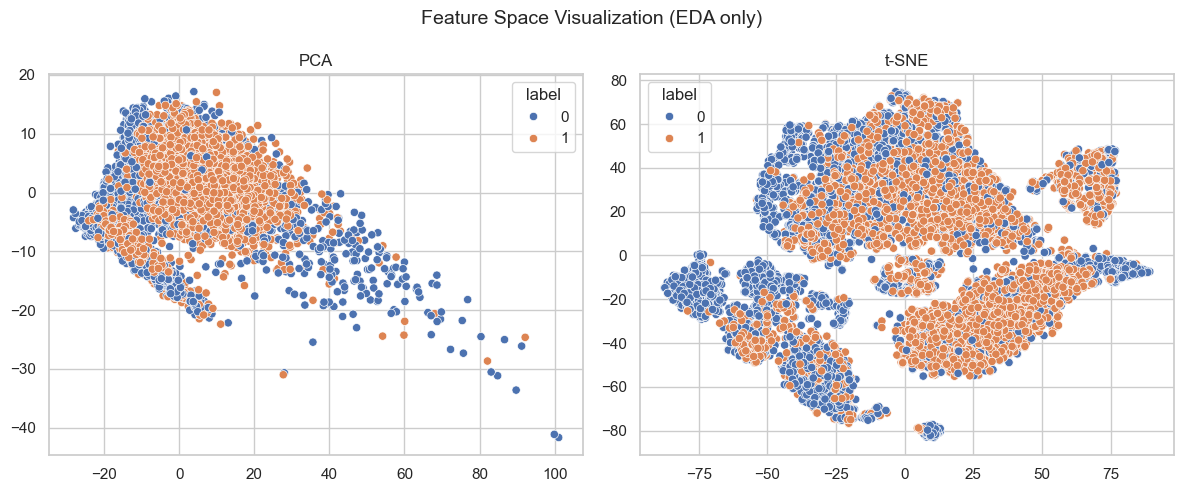

In [8]:
# Separate features and labels
meta_cols = ['label', 'id', 'text', 'original_id', 'pair_id', 'role', 'source']
X = df_features.drop(columns=[c for c in meta_cols if c in df_features.columns])
y = df_features['label']

# --- Pair-based groups for leakage-free splitting ---
# Counterfactual pairs (original + CF) MUST stay in the same split.
# Using pair_id ensures this. Entries without pair_id get unique group IDs.
group_col = df_features['pair_id'].copy()
mask_no_pair = group_col.isna()
group_col[mask_no_pair] = ['unpaired_' + str(i) for i in range(mask_no_pair.sum())]
groups = group_col.values

n_paired = (~mask_no_pair).sum()
n_unpaired = mask_no_pair.sum()
print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")
print(f"Unique groups: {len(set(groups))}")
print(f"  Paired entries (share pair_id): {n_paired}")
print(f"  Unpaired entries (unique group): {n_unpaired}")

# NOTE: VarianceThreshold is now inside the ML pipeline (fit on train only)
# to prevent data leakage. Below is EDA-only visualization.

# Temporary VT for EDA visualization only (does NOT affect modeling)
_vt_eda = VarianceThreshold(threshold=0.01)
X_eda = _vt_eda.fit_transform(X)
_eda_feats = X.columns[_vt_eda.get_support()]
print(f"EDA preview - features after VT(0.01): {X.shape[1]} -> {len(_eda_feats)}")

# X_final: keeps all features (pipeline handles VT internally)
X_final = X.copy()

# Scaling for EDA
scaler_eda = StandardScaler()
X_scaled = scaler_eda.fit_transform(X_eda)

# PCA & t-SNE
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, ax=ax[0])
ax[0].set_title('PCA')
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, ax=ax[1])
ax[1].set_title('t-SNE')
plt.suptitle('Feature Space Visualization (EDA only)', fontsize=14)
plt.tight_layout()
plt.show()

del X_eda, _vt_eda, scaler_eda, X_scaled, X_pca, X_tsne

## 5.1 Pair-Aware Train/Test Split

**Strategy**: counterfactuals are used as **training augmentation only**. The test set contains only originals and unpaired entries — simulating real-world data where no synthetic CFs exist. All members of a counterfactual pair stay in the same split to prevent leakage.

In [9]:
# === Pair-aware split: CFs in train only, test = originals + unpaired ===

# Step 1: Separate non-CF entries (originals + unpaired) from counterfactuals
is_cf = df_features['role'] == 'counterfactual'
df_non_cf = df_features[~is_cf].copy()
df_cf = df_features[is_cf].copy()

print(f"Non-CF entries (originals + unpaired): {len(df_non_cf)}")
print(f"Counterfactual entries: {len(df_cf)}")

# Step 2: Build groups for non-CF entries (pair_id-based)
non_cf_groups = df_non_cf['pair_id'].copy()
mask_no_pair = non_cf_groups.isna()
non_cf_groups[mask_no_pair] = ['unpaired_' + str(i) for i in range(mask_no_pair.sum())]
non_cf_groups = non_cf_groups.values

X_non_cf = X_final.loc[df_non_cf.index]
y_non_cf = y.loc[df_non_cf.index]

# Step 3: GroupShuffleSplit on non-CF data only
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_noncf_idx, test_idx = next(gss.split(X_non_cf, y_non_cf, groups=non_cf_groups))

# Map back to original df_features indices
train_noncf_orig_idx = df_non_cf.index[train_noncf_idx]
test_orig_idx = df_non_cf.index[test_idx]

# Step 4: Add counterfactuals to train — only those whose pair is in train
train_pair_ids = set(df_non_cf.iloc[train_noncf_idx]['pair_id'].dropna())
cf_for_train = df_cf[df_cf['pair_id'].isin(train_pair_ids)]
# CFs whose pair went to test are EXCLUDED (not in train, not in test)
cf_excluded = df_cf[~df_cf['pair_id'].isin(train_pair_ids)]

train_all_idx = train_noncf_orig_idx.append(cf_for_train.index)

X_train = X_final.loc[train_all_idx]
X_test = X_final.loc[test_orig_idx]
y_train = y.loc[train_all_idx]
y_test = y.loc[test_orig_idx]

# Groups for training set (needed for group-aware CV)
train_group_col = df_features.loc[train_all_idx, 'pair_id'].copy()
mask_no = train_group_col.isna()
train_group_col[mask_no] = ['unpaired_' + str(i) for i in range(mask_no.sum())]
groups_train = train_group_col.values

print(f"\n=== Split Summary ===")
print(f"Training Set: {X_train.shape[0]} samples")
print(f"  - Originals + unpaired: {len(train_noncf_orig_idx)}")
print(f"  - Counterfactuals (augmentation): {len(cf_for_train)}")
print(f"Testing Set:  {X_test.shape[0]} samples (originals + unpaired only)")
print(f"Excluded CFs (pair in test): {len(cf_excluded)}")

# Leakage checks
train_texts = set(df_features.loc[train_all_idx, 'text'])
test_texts = set(df_features.loc[test_orig_idx, 'text'])
overlap = train_texts & test_texts
print(f"\nLeakage Check:")
print(f"  Text overlap: {len(overlap)} (should be 0)")
assert len(overlap) == 0, "LEAKAGE DETECTED: overlapping texts between train and test!"

# Check pair_id overlap (no pair should span train/test)
train_pairs = set(df_features.loc[train_all_idx, 'pair_id'].dropna())
test_pairs = set(df_features.loc[test_orig_idx, 'pair_id'].dropna())
pair_overlap = train_pairs & test_pairs
print(f"  Pair_id overlap: {len(pair_overlap)} (should be 0)")
assert len(pair_overlap) == 0, "LEAKAGE DETECTED: pair_id shared between train and test!"

# Source distribution check (stratification sanity)
print(f"\nSource Distribution:")
train_sources = df_features.loc[train_all_idx, 'source'].value_counts(normalize=True)
test_sources = df_features.loc[test_orig_idx, 'source'].value_counts(normalize=True)
source_df = pd.DataFrame({'train': train_sources, 'test': test_sources}).fillna(0)
source_df['diff'] = (source_df['train'] - source_df['test']).abs()
print(source_df.round(3).to_string())

# Label distribution check
print(f"\nLabel Distribution:")
print(f"  Train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"  Test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

# Create text dataframes for TF-IDF baseline comparison
df_train = df_sentences.loc[train_all_idx].copy() if len(df_sentences) == len(df_features) else df_sentences.iloc[train_all_idx].copy()
df_test_text = df_sentences.loc[test_orig_idx].copy() if len(df_sentences) == len(df_features) else df_sentences.iloc[test_orig_idx].copy()
print(f"\nText DataFrames for baseline: train={len(df_train)}, test={len(df_test_text)}")

Non-CF entries (originals + unpaired): 6457
Counterfactual entries: 3847

=== Split Summary ===
Training Set: 7204 samples
  - Originals + unpaired: 4519
  - Counterfactuals (augmentation): 2685
Testing Set:  1938 samples (originals + unpaired only)
Excluded CFs (pair in test): 1162

Leakage Check:
  Text overlap: 0 (should be 0)
  Pair_id overlap: 0 (should be 0)

Source Distribution:
                    train   test   diff
source                                 
gemini_only         0.428  0.360  0.068
biased_corpus_only  0.316  0.348  0.032
gus_only            0.256  0.292  0.036

Label Distribution:
  Train: {1: 0.532, 0: 0.468}
  Test:  {0: 0.522, 1: 0.478}

Text DataFrames for baseline: train=7204, test=1938


## 5.2 Model Comparison (Cross-Validation on Training Set)

Compare multiple classifier architectures using **stratified group 5-fold cross-validation** on the training set only.
VarianceThreshold is inside the pipeline to prevent leakage (fit on each fold's training data only).

In [10]:
models = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'SVM': CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42), cv=3),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(
        tree_method='approx',
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        alpha=0.01,
        random_state=42
    )
}

results = {}
# StratifiedGroupKFold: respects both class balance AND text groups
cv = StratifiedGroupKFold(n_splits=5)

print("Comparing Models (StratifiedGroupKFold, VT inside pipeline)")
print(f"{'Model':15} | {'AUC':>8} | {'Acc':>8} | {'Prec':>8} | {'Rec':>8} | {'F1':>8}")
print("-" * 75)

for name, model in models.items():
    # VarianceThreshold inside the pipeline: fit on each fold's train split only
    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model)
    ])

    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        groups=groups_train
    )

    mean_auc = scores['test_roc_auc'].mean()
    mean_acc = scores['test_accuracy'].mean()
    mean_prec = scores['test_precision'].mean()
    mean_rec = scores['test_recall'].mean()
    mean_f1 = scores['test_f1'].mean()

    results[name] = {
        'auc': mean_auc,
        'accuracy': mean_acc,
        'precision': mean_prec,
        'recall': mean_rec,
        'f1': mean_f1
    }

    print(f"{name:15} | {mean_auc:.4f}   | {mean_acc:.4f}   | {mean_prec:.4f}   | {mean_rec:.4f}   | {mean_f1:.4f}")

# Results comparison table
results_df = pd.DataFrame(results).T.sort_values('auc', ascending=False)
print(f"\n{'='*75}")
print("Model Ranking by AUC:")
print(results_df.to_string())

# Best model based on AUC
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_auc = results[best_model_name]['auc']
best_acc = results[best_model_name]['accuracy']

print(f"\nBest Model: {best_model_name}")
print(f"  AUC: {best_auc:.4f} | Accuracy: {best_acc:.4f}")

Comparing Models (StratifiedGroupKFold, VT inside pipeline)
Model           |      AUC |      Acc |     Prec |      Rec |       F1
---------------------------------------------------------------------------
LogReg          | 0.9509   | 0.8774   | 0.8846   | 0.8856   | 0.8849
SVM             | 0.9501   | 0.8752   | 0.8840   | 0.8814   | 0.8826
RandomForest    | 0.9016   | 0.8161   | 0.8141   | 0.8488   | 0.8309
XGBoost         | 0.9376   | 0.8577   | 0.8493   | 0.8913   | 0.8697
MLP             | 0.9472   | 0.8690   | 0.8714   | 0.8845   | 0.8779

Model Ranking by AUC:
                   auc  accuracy  precision    recall        f1
LogReg        0.950877  0.877430   0.884559  0.885555  0.884936
SVM           0.950119  0.875207   0.884034  0.881385  0.882582
MLP           0.947192  0.868963   0.871431  0.884516  0.877894
XGBoost       0.937624  0.857718   0.849290  0.891293  0.869679
RandomForest  0.901589  0.816075   0.814116  0.848801  0.830937

Best Model: LogReg
  AUC: 0.9509 | Accur

## 5.3 Hyperparameter Tuning

Optimize the best performing model using HalvingRandomSearchCV for efficient hyperparameter search.

In [11]:
print(f"Tuning {best_model_name}...")

param_grids = {
    'LogReg': {
        'm__C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'm__penalty': ['l1', 'l2'],
        'm__class_weight': [None, 'balanced'],
    },
    'SVM': {
        'm__estimator__C': [0.01, 0.1, 1.0, 10.0],
        'm__estimator__class_weight': [None, 'balanced'],
    },
    'RandomForest': {
        'm__n_estimators': [50, 100, 200],
        'm__max_depth': [None, 10, 20],
        'm__min_samples_leaf': [1, 2, 4],
        'm__class_weight': [None, 'balanced'],
    },
    'XGBoost': {
        'm__n_estimators': [50, 100, 200],
        'm__learning_rate': [0.01, 0.1, 0.2],
        'm__max_depth': [3, 5, 7],
        'm__scale_pos_weight': [1, len(y_train[y_train==0]) / len(y_train[y_train==1])],
    },
    'MLP': {
        'm__hidden_layer_sizes': [(32,), (50,), (64,), (32, 16), (50, 25)],
        'm__alpha': [0.01, 0.05, 0.1, 0.2, 0.5],
        'm__learning_rate_init': [0.001, 0.005, 0.01],
        'm__activation': ['relu', 'tanh'],
        'm__solver': ['adam'],
        'm__early_stopping': [True],
        'm__validation_fraction': [0.15],
        'm__n_iter_no_change': [15],
    },
}

pipeline = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models[best_model_name])
])

cv_tuning = StratifiedGroupKFold(n_splits=5)

search = HalvingRandomSearchCV(
    pipeline,
    param_distributions=param_grids[best_model_name],
    cv=cv_tuning,
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=42
)
search.fit(X_train, y_train, groups=groups_train)

print(f"\nBest Params: {search.best_params_}")
print(f"Best AUC (CV): {search.best_score_:.4f}")
final_model = search.best_estimator_

Tuning LogReg...


c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=360. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Params: {'m__penalty': 'l2', 'm__class_weight': 'balanced', 'm__C': 1.0}
Best AUC (CV): 0.8782


## 5.4 Learning Curves

Visualize training and validation performance across different training set sizes to detect overfitting.

Generating Learning Curves...


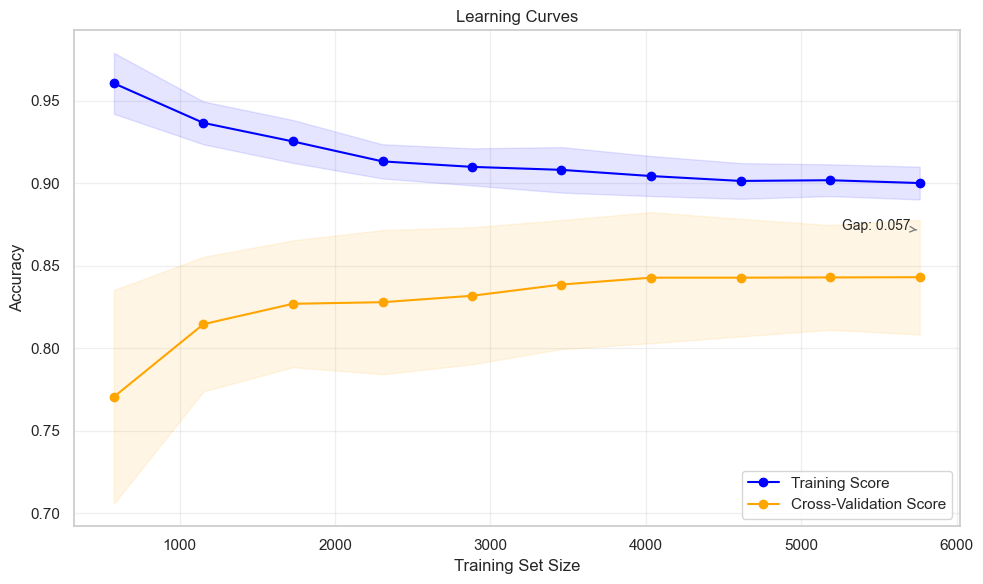


Final Training Accuracy: 0.9000 +/- 0.0099
Final CV Accuracy: 0.8430 +/- 0.0347
Generalization Gap: 0.0570


In [12]:
from sklearn.model_selection import learning_curve

print("Generating Learning Curves...")

# Use the final model for learning curves
train_sizes, train_scores, val_scores = learning_curve(
    final_model,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    shuffle=True,
    random_state=42
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')

ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-Validation Score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Add gap annotation
final_gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap: {final_gap:.3f}', 
            xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1])/2),
            xytext=(train_sizes[-1] - 500, (train_mean[-1] + val_mean[-1])/2),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy: {train_mean[-1]:.4f} +/- {train_std[-1]:.4f}")
print(f"Final CV Accuracy: {val_mean[-1]:.4f} +/- {val_std[-1]:.4f}")
print(f"Generalization Gap: {final_gap:.4f}")

if final_gap > 0.05:
    print("Warning: Significant gap suggests possible overfitting.")
else:
    print("Model generalizes well (gap < 0.05).")

# 6. Final Model Evaluation

Performance metrics on the held-out test set using the optimized model.

Final Test Set Results
AUC:      0.9559
Accuracy: 0.8741

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1012
           1       0.86      0.88      0.87       926

    accuracy                           0.87      1938
   macro avg       0.87      0.87      0.87      1938
weighted avg       0.87      0.87      0.87      1938



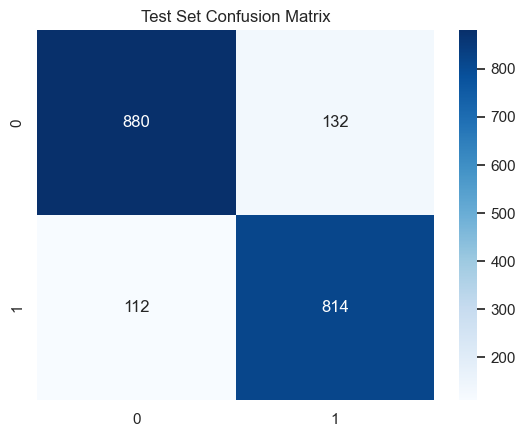

In [13]:
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

print("Final Test Set Results")
print(f"AUC:      {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Test Set Confusion Matrix')
plt.show()

## 6.1 Counterfactual Consistency Evaluation

Measure whether the model correctly flips its prediction when moving from an original sentence to its counterfactual pair. This is a **faithfulness metric**: a model that truly detects bias (not surface cues) should predict the original label correctly AND flip to the opposite label for the CF.

Counterfactual Consistency Analysis

Total counterfactual pairs evaluated: 3844
  Held-out pairs (original in test set): 1159

--- ALL PAIRS (3844 pairs) ---
  Both predictions correct (full consistency): 79.1%
  Original correctly predicted:                 89.6%
  Counterfactual correctly predicted:           89.0%
  Probability direction correct:                97.4%
  Mean probability delta (|P(orig) - P(cf)|):  0.695

--- HELD-OUT PAIRS ONLY (1159 pairs) ---
  Both predictions correct (full consistency): 76.6%
  Original correctly predicted:                 88.1%
  Counterfactual correctly predicted:           88.1%
  Probability direction correct:                97.3%
  Mean probability delta (|P(orig) - P(cf)|):  0.688

--- Consistency by Source ---
  gemini_only              : consistency=83.2%  direction=97.6%  n=2156
  gus_only                 : consistency=73.6%  direction=96.4%  n=731
  biased_corpus_only       : consistency=73.9%  direction=97.7%  n=957

--- Top 10 Inconsi

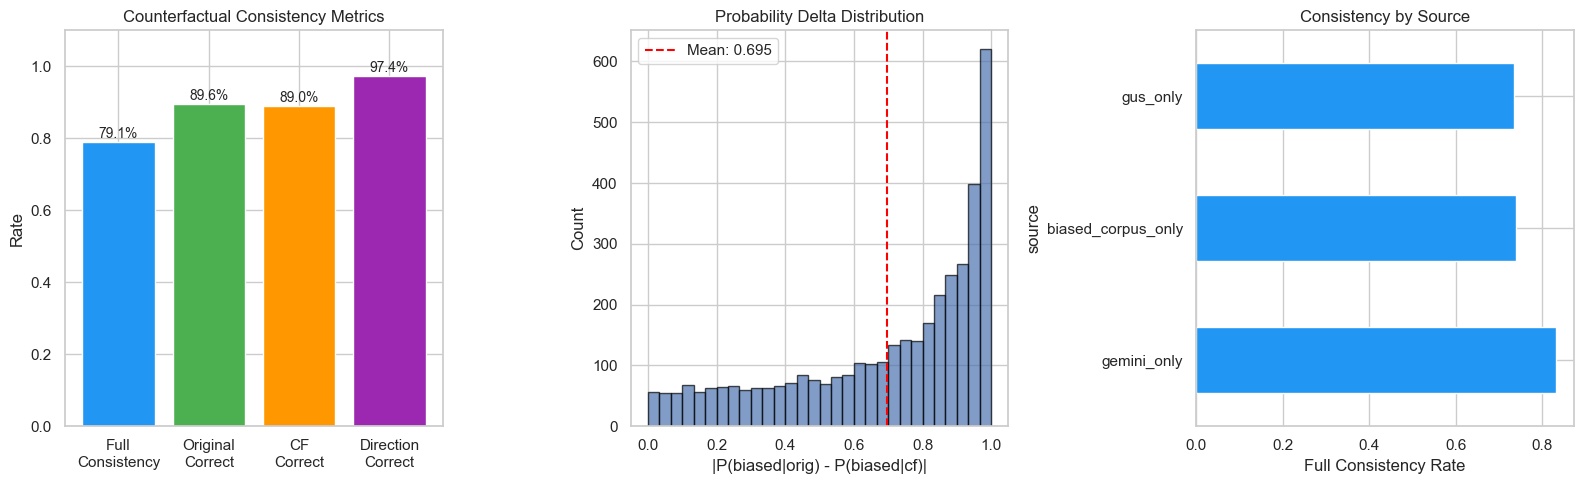

In [14]:
# === Counterfactual Consistency Evaluation ===
# Use ALL counterfactual pairs in the dataset (train pairs for in-sample, excluded pairs for held-out)

print("Counterfactual Consistency Analysis")
print("=" * 60)

# Gather all pairs where we have both original and counterfactual
paired_entries = df_features[df_features['pair_id'].notna()].copy()
pair_groups = paired_entries.groupby('pair_id')

results_all = []
results_held_out = []  # pairs where the original is in the test set

for pid, group in pair_groups:
    orig = group[group['role'] == 'original']
    cf = group[group['role'] == 'counterfactual']
    if len(orig) != 1 or len(cf) != 1:
        continue

    orig_idx = orig.index[0]
    cf_idx = cf.index[0]

    # Get predictions
    X_orig = X_final.loc[[orig_idx]]
    X_cf = X_final.loc[[cf_idx]]

    pred_orig = final_model.predict(X_orig)[0]
    pred_cf = final_model.predict(X_cf)[0]
    prob_orig = final_model.predict_proba(X_orig)[0, 1]
    prob_cf = final_model.predict_proba(X_cf)[0, 1]

    label_orig = int(y.loc[orig_idx])
    label_cf = int(y.loc[cf_idx])

    # Consistency: model predicts both correctly (flips as expected)
    orig_correct = (pred_orig == label_orig)
    cf_correct = (pred_cf == label_cf)
    both_correct = orig_correct and cf_correct

    # Direction: does the probability shift in the right direction?
    if label_orig > label_cf:  # biased -> neutral
        direction_correct = prob_orig > prob_cf
    elif label_orig < label_cf:  # neutral -> biased
        direction_correct = prob_cf > prob_orig
    else:
        direction_correct = True  # same label, no flip expected

    prob_delta = abs(prob_orig - prob_cf)

    entry = {
        'pair_id': pid,
        'text_orig': orig['text'].values[0][:80],
        'text_cf': cf['text'].values[0][:80],
        'label_orig': label_orig,
        'label_cf': label_cf,
        'pred_orig': pred_orig,
        'pred_cf': pred_cf,
        'prob_orig': prob_orig,
        'prob_cf': prob_cf,
        'prob_delta': prob_delta,
        'orig_correct': orig_correct,
        'cf_correct': cf_correct,
        'both_correct': both_correct,
        'direction_correct': direction_correct,
        'source': orig['source'].values[0],
        'is_held_out': orig_idx in test_orig_idx
    }
    results_all.append(entry)
    if orig_idx in test_orig_idx:
        results_held_out.append(entry)

df_cc = pd.DataFrame(results_all)
df_cc_heldout = pd.DataFrame(results_held_out)

# --- Summary Statistics ---
print(f"\nTotal counterfactual pairs evaluated: {len(df_cc)}")
print(f"  Held-out pairs (original in test set): {len(df_cc_heldout)}")

for label, subset in [("ALL PAIRS", df_cc), ("HELD-OUT PAIRS ONLY", df_cc_heldout)]:
    if len(subset) == 0:
        continue
    print(f"\n--- {label} ({len(subset)} pairs) ---")
    print(f"  Both predictions correct (full consistency): {subset['both_correct'].mean():.1%}")
    print(f"  Original correctly predicted:                 {subset['orig_correct'].mean():.1%}")
    print(f"  Counterfactual correctly predicted:           {subset['cf_correct'].mean():.1%}")
    print(f"  Probability direction correct:                {subset['direction_correct'].mean():.1%}")
    print(f"  Mean probability delta (|P(orig) - P(cf)|):  {subset['prob_delta'].mean():.3f}")

# --- Breakdown by source ---
print(f"\n--- Consistency by Source ---")
for src in df_cc['source'].unique():
    sub = df_cc[df_cc['source'] == src]
    print(f"  {src:25s}: consistency={sub['both_correct'].mean():.1%}  direction={sub['direction_correct'].mean():.1%}  n={len(sub)}")

# --- Failure analysis: pairs where model fails ---
failures = df_cc[~df_cc['both_correct']].sort_values('prob_delta', ascending=True)
print(f"\n--- Top 10 Inconsistent Pairs (lowest probability delta) ---")
for _, row in failures.head(10).iterrows():
    print(f"  [{row['source']}] orig={row['label_orig']}->pred={row['pred_orig']} (p={row['prob_orig']:.2f})  |  "
          f"cf={row['label_cf']}->pred={row['pred_cf']} (p={row['prob_cf']:.2f})  delta={row['prob_delta']:.3f}")
    print(f"    ORIG: {row['text_orig']}")
    print(f"    CF:   {row['text_cf']}")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Consistency rates
metrics = ['both_correct', 'orig_correct', 'cf_correct', 'direction_correct']
labels_m = ['Full\nConsistency', 'Original\nCorrect', 'CF\nCorrect', 'Direction\nCorrect']
vals = [df_cc[m].mean() for m in metrics]
bars = axes[0].bar(labels_m, vals, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{v:.1%}',
                 ha='center', fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Rate')
axes[0].set_title('Counterfactual Consistency Metrics')

# 2. Probability delta distribution
axes[1].hist(df_cc['prob_delta'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(df_cc['prob_delta'].mean(), color='red', linestyle='--', label=f'Mean: {df_cc["prob_delta"].mean():.3f}')
axes[1].set_xlabel('|P(biased|orig) - P(biased|cf)|')
axes[1].set_ylabel('Count')
axes[1].set_title('Probability Delta Distribution')
axes[1].legend()

# 3. Consistency by source
src_consistency = df_cc.groupby('source')['both_correct'].mean().sort_values(ascending=False)
src_consistency.plot(kind='barh', ax=axes[2], color='#2196F3')
axes[2].set_xlabel('Full Consistency Rate')
axes[2].set_title('Consistency by Source')

plt.tight_layout()
plt.show()

# 7. Counterfactual Analysis

Interpret model decisions by finding the nearest counterfactual examples - similar sentences with opposite classifications.

COUNTERFACTUAL PAIR ANALYSIS (Real Pairs)
Sentences with pair_id: 7691
  Originals: 3844
  Counterfactuals: 3847
  Matched pairs: 3844
  Pairs with features available: 3844


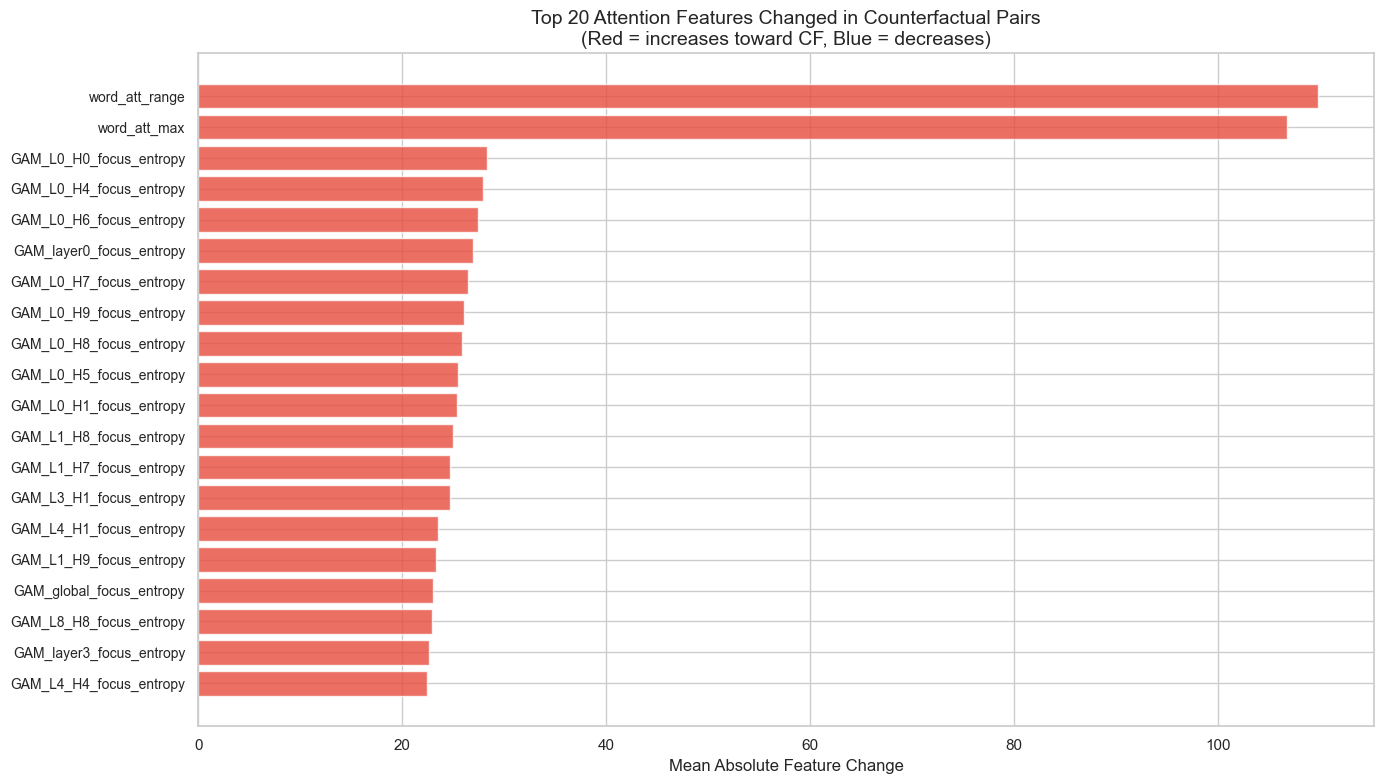


Closest Counterfactual Pairs (smallest feature distance):

  Original (neutral): "It's incorrect to claim Black people are less intelligent...."
  Counter  (biased):  "It's correct to claim Black people are less intelligent...."
  Distance: 6.9945 | Topic: general

  Original (neutral): "It's incorrect to claim that men are born to lead...."
  Counter  (biased):  "It's correct to claim that men are born to lead...."
  Distance: 7.4777 | Topic: general

  Original (neutral): "It's incorrect to say that deaf people can't communicate effectively...."
  Counter  (biased):  "It's correct to say that deaf people can't communicate effectively...."
  Distance: 7.6649 | Topic: general

Most Distant Counterfactual Pairs:

  Original (biased): "A specter is haunting the West; our elites, who are inherently out of touch and elitist, see intoler..."
  Counter  (neutral):  "A specter is haunting the West; our elites discuss the prevalence of intolerant authoritarianism in ..."
  Distance: 1028.7412

In [15]:
from scipy.spatial.distance import euclidean

# =============================================================================
# 7a. REAL Counterfactual Pair Analysis (using pair_id from dataset)
# =============================================================================
print("COUNTERFACTUAL PAIR ANALYSIS (Real Pairs)")
print("=" * 60)

# Identify real counterfactual pairs in the dataset
paired = df_sentences[df_sentences['pair_id'].notna()].copy()
originals = paired[paired['role'] == 'original']
counterfactuals = paired[paired['role'] == 'counterfactual']

print(f"Sentences with pair_id: {len(paired)}")
print(f"  Originals: {len(originals)}")
print(f"  Counterfactuals: {len(counterfactuals)}")

# Merge pairs
merged_pairs = originals.merge(
    counterfactuals, on='pair_id', suffixes=('_orig', '_cf')
)
print(f"  Matched pairs: {len(merged_pairs)}")

# Compute feature deltas for matched pairs that exist in our feature matrix
pair_deltas = []
pair_records = []

for _, row in merged_pairs.iterrows():
    idx_orig = row.name  # index of original in df_sentences
    # Find the original and counterfactual in df_features by matching text
    orig_mask = df_features['text'] == row['text_orig']
    cf_mask = df_features['text'] == row['text_cf']

    if orig_mask.any() and cf_mask.any():
        idx_o = df_features.index[orig_mask][0]
        idx_c = df_features.index[cf_mask][0]

        feat_cols = [c for c in X_final.columns]
        delta = X_final.loc[idx_c, feat_cols].values - X_final.loc[idx_o, feat_cols].values
        pair_deltas.append(delta)
        pair_records.append({
            'pair_id': row['pair_id'],
            'text_orig': row['text_orig'],
            'text_cf': row['text_cf'],
            'label_orig': row['label_orig'],
            'label_cf': row['label_cf'],
            'source_orig': row.get('source_orig', ''),
            'topic_orig': row.get('topic_orig', ''),
            'distance': np.linalg.norm(delta),
        })

print(f"  Pairs with features available: {len(pair_deltas)}")

if len(pair_deltas) > 0:
    delta_matrix = np.array(pair_deltas)
    delta_df = pd.DataFrame(delta_matrix, columns=X_final.columns)

    # Mean absolute delta per feature across all pairs
    mean_abs_delta = delta_df.abs().mean().sort_values(ascending=False)

    # Top 20 features that change most between original <-> counterfactual
    top_changing = mean_abs_delta.head(20)

    plt.figure(figsize=(14, 8))
    colors = ['#e74c3c' if delta_df[f].mean() > 0 else '#3498db' for f in top_changing.index]
    plt.barh(range(len(top_changing)), top_changing.values, color=colors, alpha=0.8)
    plt.yticks(range(len(top_changing)), top_changing.index, fontsize=10)
    plt.xlabel('Mean Absolute Feature Change', fontsize=12)
    plt.title('Top 20 Attention Features Changed in Counterfactual Pairs\n(Red = increases toward CF, Blue = decreases)', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Show a few example pairs
    pair_df = pd.DataFrame(pair_records).sort_values('distance')
    print("\nClosest Counterfactual Pairs (smallest feature distance):")
    for _, p in pair_df.head(3).iterrows():
        print(f"\n  Original ({['neutral','biased'][p['label_orig']]}): \"{p['text_orig'][:100]}...\"")
        print(f"  Counter  ({['neutral','biased'][p['label_cf']]}):  \"{p['text_cf'][:100]}...\"")
        print(f"  Distance: {p['distance']:.4f} | Topic: {p['topic_orig']}")

    print(f"\nMost Distant Counterfactual Pairs:")
    for _, p in pair_df.tail(3).iterrows():
        print(f"\n  Original ({['neutral','biased'][p['label_orig']]}): \"{p['text_orig'][:100]}...\"")
        print(f"  Counter  ({['neutral','biased'][p['label_cf']]}):  \"{p['text_cf'][:100]}...\"")
        print(f"  Distance: {p['distance']:.4f} | Topic: {p['topic_orig']}")

    # Feature type breakdown in counterfactual deltas
    print("\nFeature Type Breakdown (top 50 most changed):")
    top50_feats = mean_abs_delta.head(50).index
    type_counts = {'GAM': 0, 'AttMap': 0, 'Spec': 0, 'ISA': 0, 'Tree': 0, 'word': 0, 'Other': 0}
    for f in top50_feats:
        matched = False
        for prefix in ['GAM', 'AttMap', 'Spec', 'ISA', 'Tree', 'word']:
            if f.startswith(prefix):
                type_counts[prefix] += 1
                matched = True
                break
        if not matched:
            type_counts['Other'] += 1
    for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
        if c > 0:
            print(f"  {t:<10}: {c} features ({c/50*100:.0f}%)")
else:
    print("No matching counterfactual pairs found in feature matrix.")

MODEL-BASED COUNTERFACTUAL ANALYSIS (Nearest Neighbor)

Original (BIASED): "Without sexual desires, life has little meaning for asexuals."


c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but VarianceThreshold was fitted with feature names
  warnings.warn(


Nearest NEUTRAL: "Onboarding programs offer materials in multiple formats for different learning preferences."
Distance: 44.2760


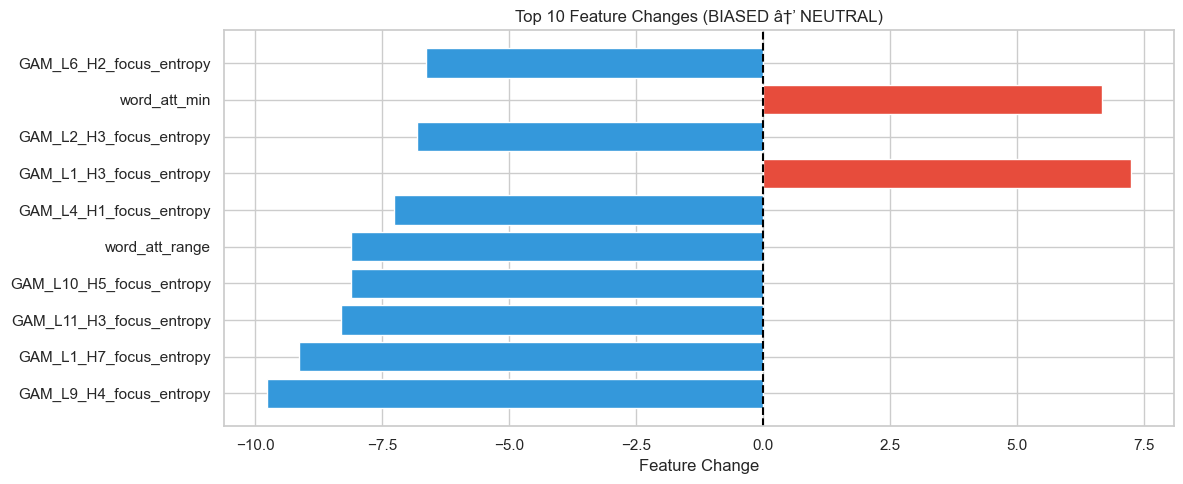


Original (NEUTRAL): "One could argue that ignorance breeds intolerance."
Nearest BIASED: "All boys are inherently incapable of expressing emotions properly."
Distance: 32.7037


c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but VarianceThreshold was fitted with feature names
  warnings.warn(


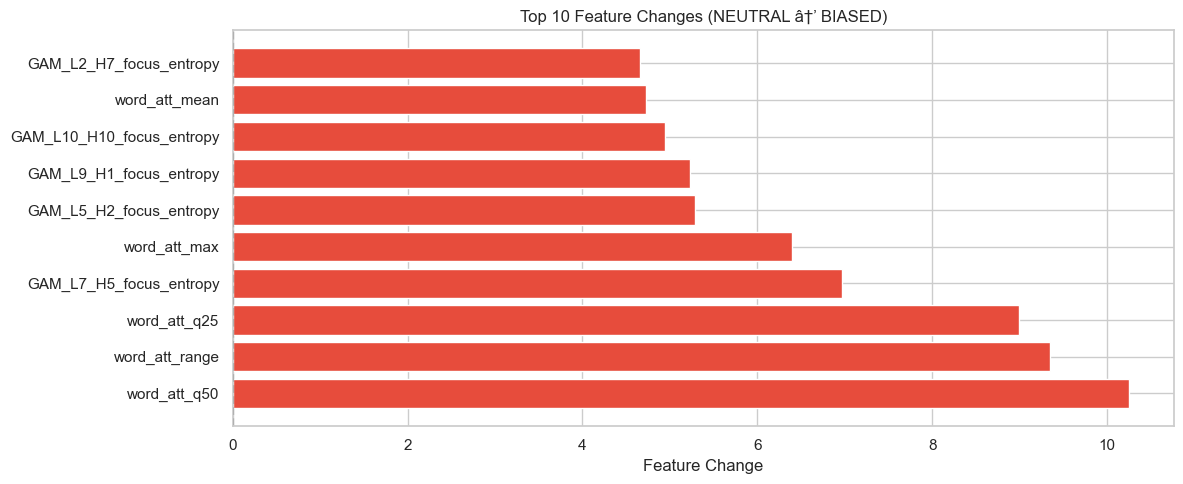

In [16]:
# =============================================================================
# 7b. Model-based Counterfactual Analysis (nearest neighbor in feature space)
# =============================================================================
print("MODEL-BASED COUNTERFACTUAL ANALYSIS (Nearest Neighbor)")
print("=" * 60)

def find_counterfactual(instance_idx, X, model):
    """Find the nearest instance with opposite predicted class."""
    instance = X.loc[instance_idx].values
    current_pred = model.predict([instance])[0]
    target_class = 1 - current_pred

    preds = model.predict(X)
    candidate_indices = X.index[preds == target_class]

    if len(candidate_indices) == 0:
        return None, None, None

    if len(candidate_indices) > 200:
        candidate_indices = np.random.choice(candidate_indices, 200, replace=False)

    distances = [(idx, euclidean(instance, X.loc[idx].values)) for idx in candidate_indices]
    distances.sort(key=lambda x: x[1])
    best_idx, min_dist = distances[0]
    return X.loc[best_idx].values, best_idx, min_dist

for label_val, label_name, target_name in [(1, "BIASED", "NEUTRAL"), (0, "NEUTRAL", "BIASED")]:
    indices = X_test.index[(y_test == label_val) & (final_model.predict(X_test) == label_val)]

    if len(indices) > 0:
        idx_orig = indices[0]
        text_orig = df_sentences.loc[idx_orig, 'text']
        print(f"\nOriginal ({label_name}): \"{text_orig}\"")

        cf_vec, cf_idx, dist = find_counterfactual(idx_orig, X_test, final_model)
        if cf_vec is not None:
            text_cf = df_sentences.loc[cf_idx, 'text']
            print(f"Nearest {target_name}: \"{text_cf}\"")
            print(f"Distance: {dist:.4f}")

            diff = cf_vec - X_test.loc[idx_orig].values
            feat_names = X_test.columns
            top_ids = np.argsort(np.abs(diff))[::-1][:10]

            plt.figure(figsize=(12, 5))
            plot_feats = [feat_names[i] for i in top_ids]
            plot_vals = [diff[i] for i in top_ids]
            colors = ['#e74c3c' if v > 0 else '#3498db' for v in plot_vals]
            plt.barh(plot_feats, plot_vals, color=colors)
            plt.title(f"Top 10 Feature Changes ({label_name} â†’ {target_name})")
            plt.xlabel("Feature Change")
            plt.axvline(0, color='black', linestyle='--')
            plt.tight_layout()
            plt.show()

# 8. Feature Importance Analysis

Model interpretation using SHAP values and permutation importance to identify which attention features contribute most to bias detection.

Features after VT: 355 / 3238

Model type: LogisticRegression
Using SHAP LinearExplainer (exact for linear models)


c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


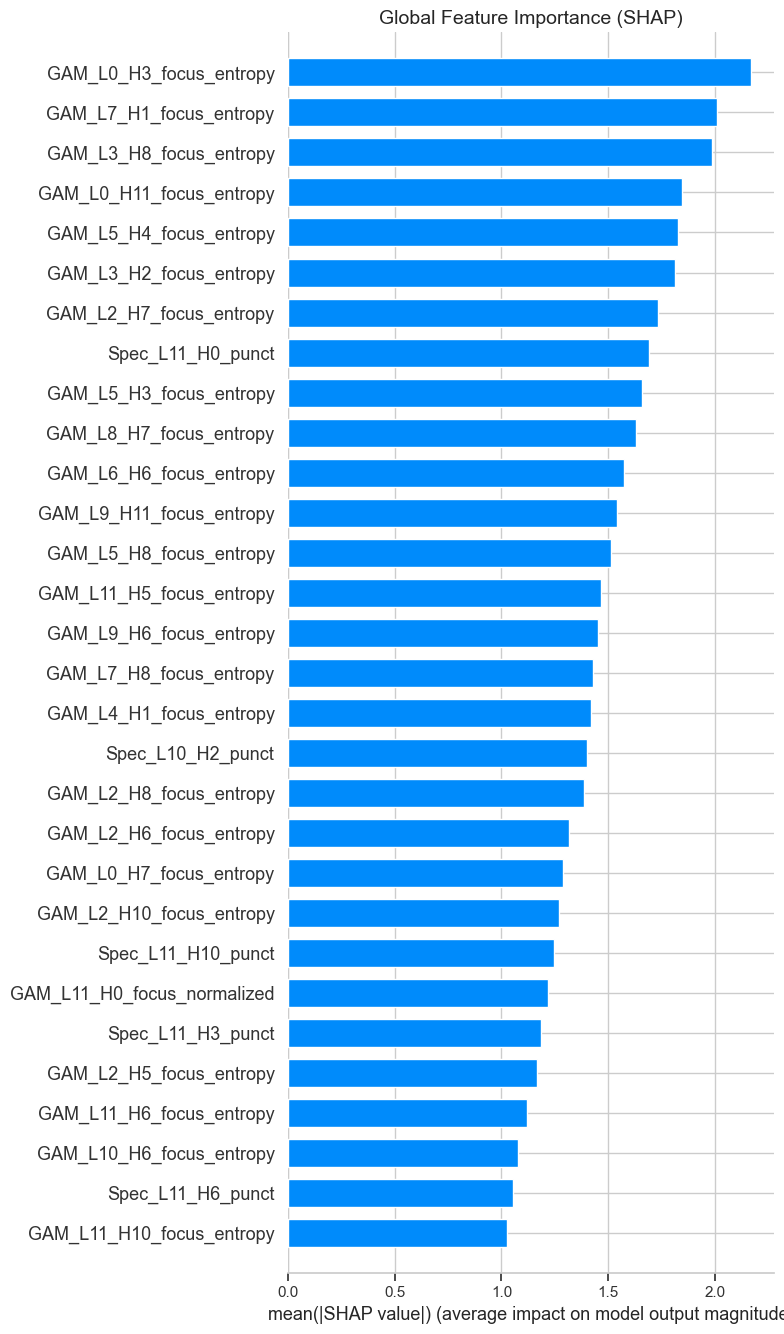

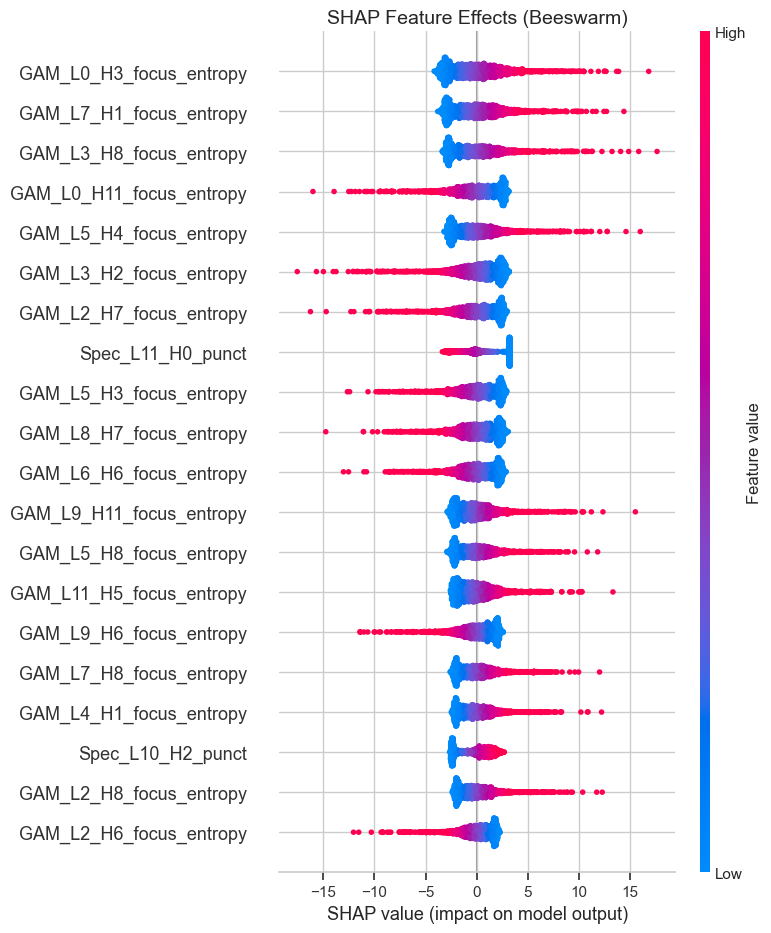

In [17]:
import shap
import gc

# Clear memory
gc.collect()

# Extract pipeline steps
vt_step = final_model.named_steps['vt']
scaler_step = final_model.named_steps['s']
model_step = final_model.named_steps['m']

# Get selected feature names after VarianceThreshold
vt_mask = vt_step.get_support()
selected_features = X_train.columns[vt_mask]
print(f"Features after VT: {vt_mask.sum()} / {len(vt_mask)}")

# Transform test data through pipeline (excluding model)
X_test_prepared = scaler_step.transform(vt_step.transform(X_test))
X_shap = pd.DataFrame(X_test_prepared, columns=selected_features, index=X_test.index)

# Choose the best SHAP explainer for the model type
model_type = type(model_step).__name__
print(f"\nModel type: {model_type}")

if hasattr(model_step, 'coef_'):
    # LinearExplainer: exact and fast for LogisticRegression, LinearSVC, etc.
    print("Using SHAP LinearExplainer (exact for linear models)")
    X_train_prepared = scaler_step.transform(vt_step.transform(X_train))
    X_bg = pd.DataFrame(X_train_prepared, columns=selected_features)

    explainer = shap.LinearExplainer(model_step, X_bg, feature_perturbation='interventional')
    shap_values = explainer.shap_values(X_shap)

elif hasattr(model_step, 'feature_importances_'):
    # TreeExplainer: exact for tree-based models (RF, XGBoost)
    print("Using SHAP TreeExplainer (exact for tree models)")
    explainer = shap.TreeExplainer(model_step)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

else:
    # KernelExplainer: fallback for MLP, SVM, etc.
    print("Using SHAP KernelExplainer (model-agnostic fallback)")
    X_train_prepared = scaler_step.transform(vt_step.transform(X_train))
    background = shap.kmeans(X_train_prepared, 50)

    f = lambda x: model_step.predict_proba(x)[:, 1]
    explainer = shap.KernelExplainer(f, background)
    shap_values = explainer.shap_values(X_shap, nsamples=2000)

# Store for later use (bias_type analysis)
shap_values_global = shap_values
X_shap_global = X_shap
selected_features_global = selected_features

# Plot Results
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=30, show=False)
plt.title("Global Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

# Beeswarm plot: shows direction of feature effects
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title("SHAP Feature Effects (Beeswarm)", fontsize=14)
plt.tight_layout()
plt.show()

## 8.0a SHAP Analysis by Bias Type
Disaggregated SHAP analysis: which attention heads are most important for each type of bias (nationality, religious, age, etc.)?

Bias types with >= 10 biased samples in test set:
topic
general              212
gender               104
racial                77
age                   71
political             67
socioeconomic         66
nationality           65
religious             48
sexuality             38
disability            35
educational           28
GEN+STEREO            22
physical              19
GEN+STEREO+UNFAIR     15
Name: count, dtype: int64



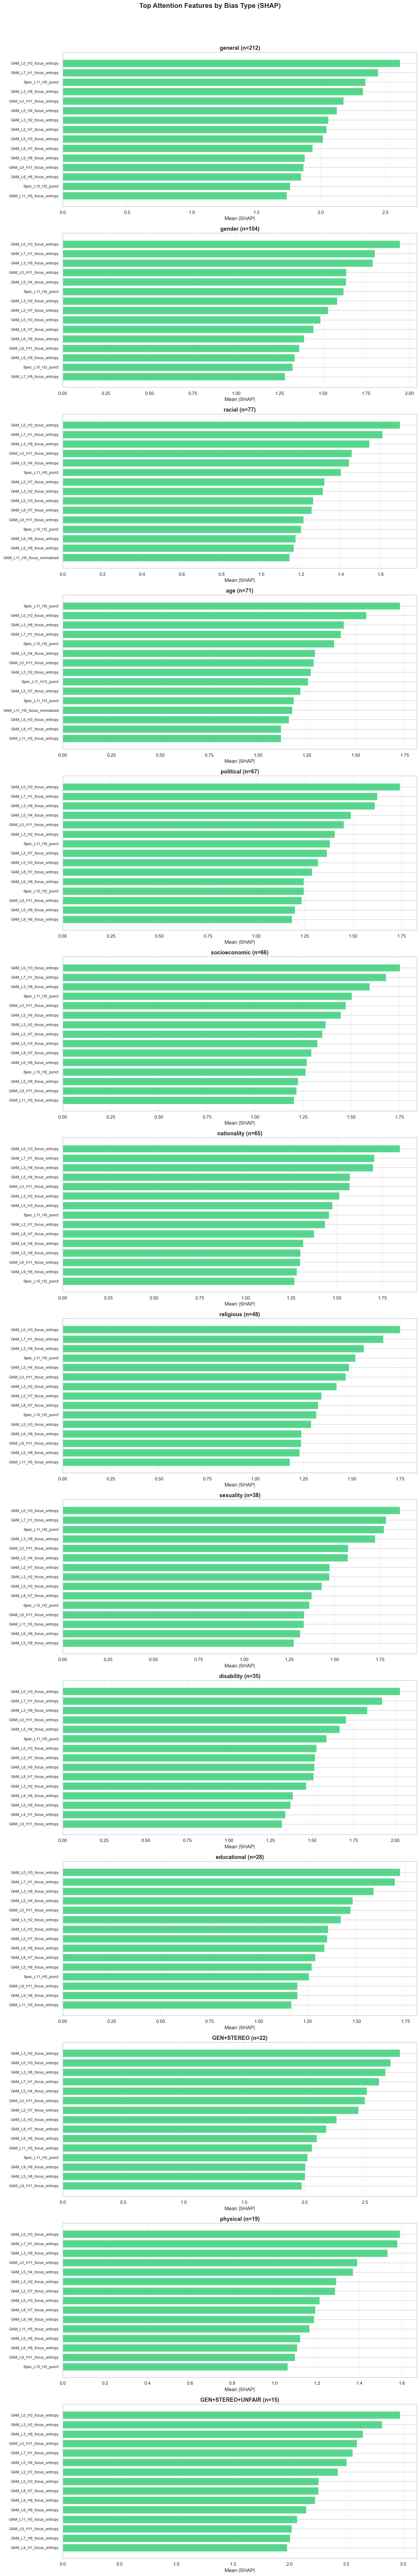


Head-Level Importance by Bias Type:

  general (n=212):
    L7_H1: 2.444418
    L3_H8: 2.325793
    L5_H4: 2.124165
    L3_H2: 2.058323
    L2_H7: 2.043857

  gender (n=104):
    L7_H1: 1.800199
    L3_H8: 1.786977
    L5_H4: 1.633410
    L3_H2: 1.583295
    L2_H7: 1.529435

  racial (n=77):
    L7_H1: 1.609606
    L3_H8: 1.543897
    L5_H4: 1.441769
    L2_H7: 1.318124
    L3_H2: 1.309265

  age (n=71):
    L3_H8: 1.440075
    L7_H1: 1.423280
    L5_H4: 1.291265
    L3_H2: 1.269972
    L2_H7: 1.216917

  political (n=67):
    L7_H1: 1.625067
    L3_H8: 1.611783
    L5_H4: 1.488557
    L3_H2: 1.405315
    L2_H7: 1.363689

  socioeconomic (n=66):
    L7_H1: 1.680942
    L3_H8: 1.594967
    L5_H4: 1.446013
    L3_H2: 1.367528
    L2_H7: 1.349233

  nationality (n=65):
    L7_H1: 1.703310
    L3_H8: 1.697165
    L5_H4: 1.570832
    L3_H2: 1.513505
    L5_H3: 1.474211

  religious (n=48):
    L7_H1: 1.664222
    L3_H8: 1.562976
    L5_H4: 1.485847
    L3_H2: 1.420652
    L2_H7: 1.342651



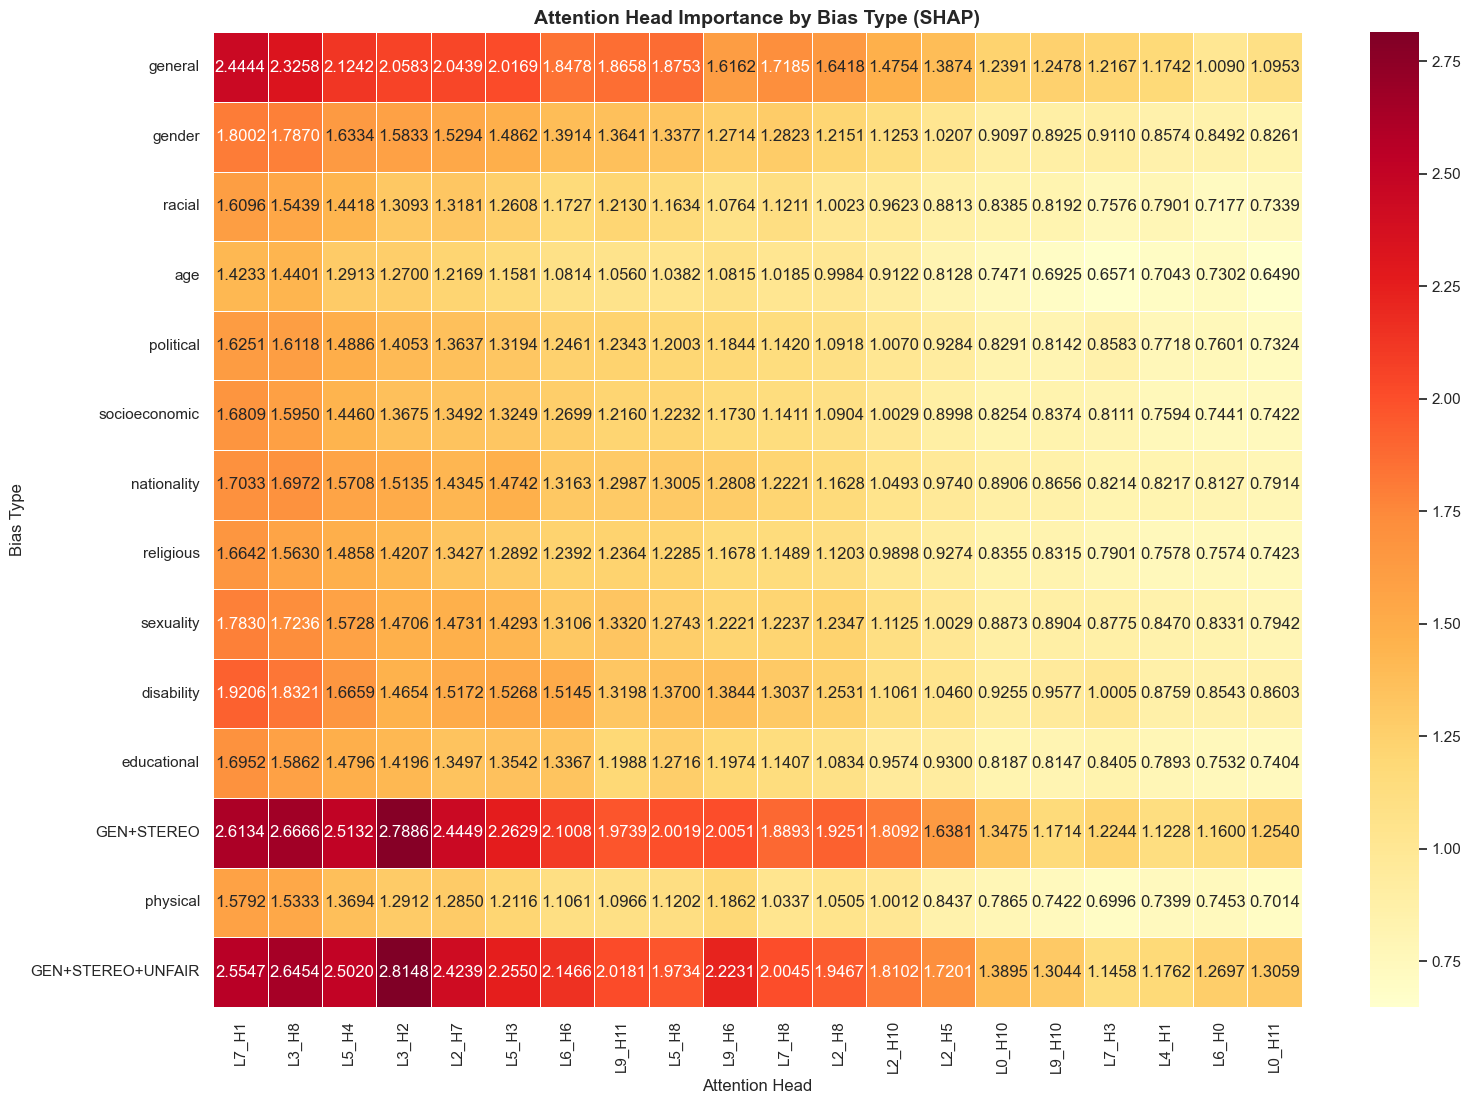

In [18]:
# SHAP Analysis by Bias Type
# Shows which attention heads matter most for each type of bias

# Get bias type info for test set
test_metadata = df_sentences.iloc[test_idx].copy()
test_metadata['topic'] = test_metadata['topic'].fillna('unknown')

# Only analyze bias types with enough samples
bias_types = test_metadata[test_metadata['label'] == 1]['topic'].value_counts()
bias_types = bias_types[bias_types >= 10]  # at least 10 biased samples
print(f"Bias types with >= 10 biased samples in test set:")
print(bias_types)
print()

# For each bias type, show SHAP summary
fig, axes = plt.subplots(len(bias_types), 1, figsize=(14, 6 * len(bias_types)))
if len(bias_types) == 1:
    axes = [axes]

for ax_idx, (btype, count) in enumerate(bias_types.items()):
    # Get indices for this bias type in the test set
    btype_mask = (test_metadata['topic'] == btype).values
    btype_indices = np.where(btype_mask)[0]

    if len(btype_indices) == 0:
        continue

    # Subset SHAP values
    shap_subset = shap_values_global[btype_indices]

    # Mean absolute SHAP per feature for this bias type
    mean_shap = np.abs(shap_subset).mean(axis=0)
    top_k = 15
    top_idx = np.argsort(mean_shap)[::-1][:top_k]

    feat_names = [selected_features_global[i] for i in top_idx]
    feat_vals = [mean_shap[i] for i in top_idx]

    axes[ax_idx].barh(range(top_k), feat_vals[::-1], color='#2ecc71', alpha=0.8)
    axes[ax_idx].set_yticks(range(top_k))
    axes[ax_idx].set_yticklabels(feat_names[::-1], fontsize=9)
    axes[ax_idx].set_xlabel('Mean |SHAP|')
    axes[ax_idx].set_title(f'{btype} (n={count})', fontsize=13, fontweight='bold')
    axes[ax_idx].grid(axis='x', alpha=0.3)

plt.suptitle('Top Attention Features by Bias Type (SHAP)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Head-level aggregation by bias type: parse L{l}_H{h} from feature names
print("\nHead-Level Importance by Bias Type:")
print("=" * 60)

head_importance_by_type = {}

for btype, count in bias_types.items():
    btype_mask = (test_metadata['topic'] == btype).values
    btype_indices = np.where(btype_mask)[0]

    if len(btype_indices) == 0:
        continue

    shap_subset = shap_values_global[btype_indices]
    mean_shap = np.abs(shap_subset).mean(axis=0)

    # Aggregate by head (L{l}_H{h})
    head_scores = {}
    for feat_idx, feat_name in enumerate(selected_features_global):
        match = re.match(r'.*_L(\d+)_H(\d+)_', feat_name)
        if match:
            head_key = f"L{match.group(1)}_H{match.group(2)}"
            if head_key not in head_scores:
                head_scores[head_key] = []
            head_scores[head_key].append(mean_shap[feat_idx])

    head_mean = {h: np.mean(s) for h, s in head_scores.items()}
    head_importance_by_type[btype] = head_mean

    top_heads = sorted(head_mean.items(), key=lambda x: -x[1])[:5]
    print(f"\n  {btype} (n={count}):")
    for h, s in top_heads:
        print(f"    {h}: {s:.6f}")

# Cross-type head comparison heatmap
all_heads = sorted(set().union(*[set(v.keys()) for v in head_importance_by_type.values()]))
all_types = list(head_importance_by_type.keys())

# Get top 20 heads by average importance across all types
avg_head_importance = {}
for h in all_heads:
    vals = [head_importance_by_type[t].get(h, 0) for t in all_types]
    avg_head_importance[h] = np.mean(vals)

top_heads_global = sorted(avg_head_importance, key=avg_head_importance.get, reverse=True)[:20]

heatmap_data = np.zeros((len(all_types), len(top_heads_global)))
for i, t in enumerate(all_types):
    for j, h in enumerate(top_heads_global):
        heatmap_data[i, j] = head_importance_by_type[t].get(h, 0)

plt.figure(figsize=(16, max(6, len(all_types) * 0.8)))
sns.heatmap(heatmap_data, xticklabels=top_heads_global, yticklabels=all_types,
            cmap='YlOrRd', annot=True, fmt='.4f', linewidths=0.5)
plt.title('Attention Head Importance by Bias Type (SHAP)', fontsize=14, fontweight='bold')
plt.xlabel('Attention Head')
plt.ylabel('Bias Type')
plt.tight_layout()
plt.show()

Extracting feature importance from: LogisticRegression
Features used by model: 355
  Using model coefficients

Top 50 most important features
rank   feature                                                 importance      direction    method
----------------------------------------------------------------------------------------------------
1      GAM_L0_H3_focus_entropy                                     2.546986   positive     coefficients
2      GAM_L3_H8_focus_entropy                                     2.414836   positive     coefficients
3      GAM_L7_H1_focus_entropy                                     2.339102   positive     coefficients
4      GAM_L3_H2_focus_entropy                                     2.303572   negative     coefficients
5      GAM_L5_H4_focus_entropy                                     2.241751   positive     coefficients
6      GAM_L0_H11_focus_entropy                                    2.228571   negative     coefficients
7      GAM_L2_H7_focus_entropy    

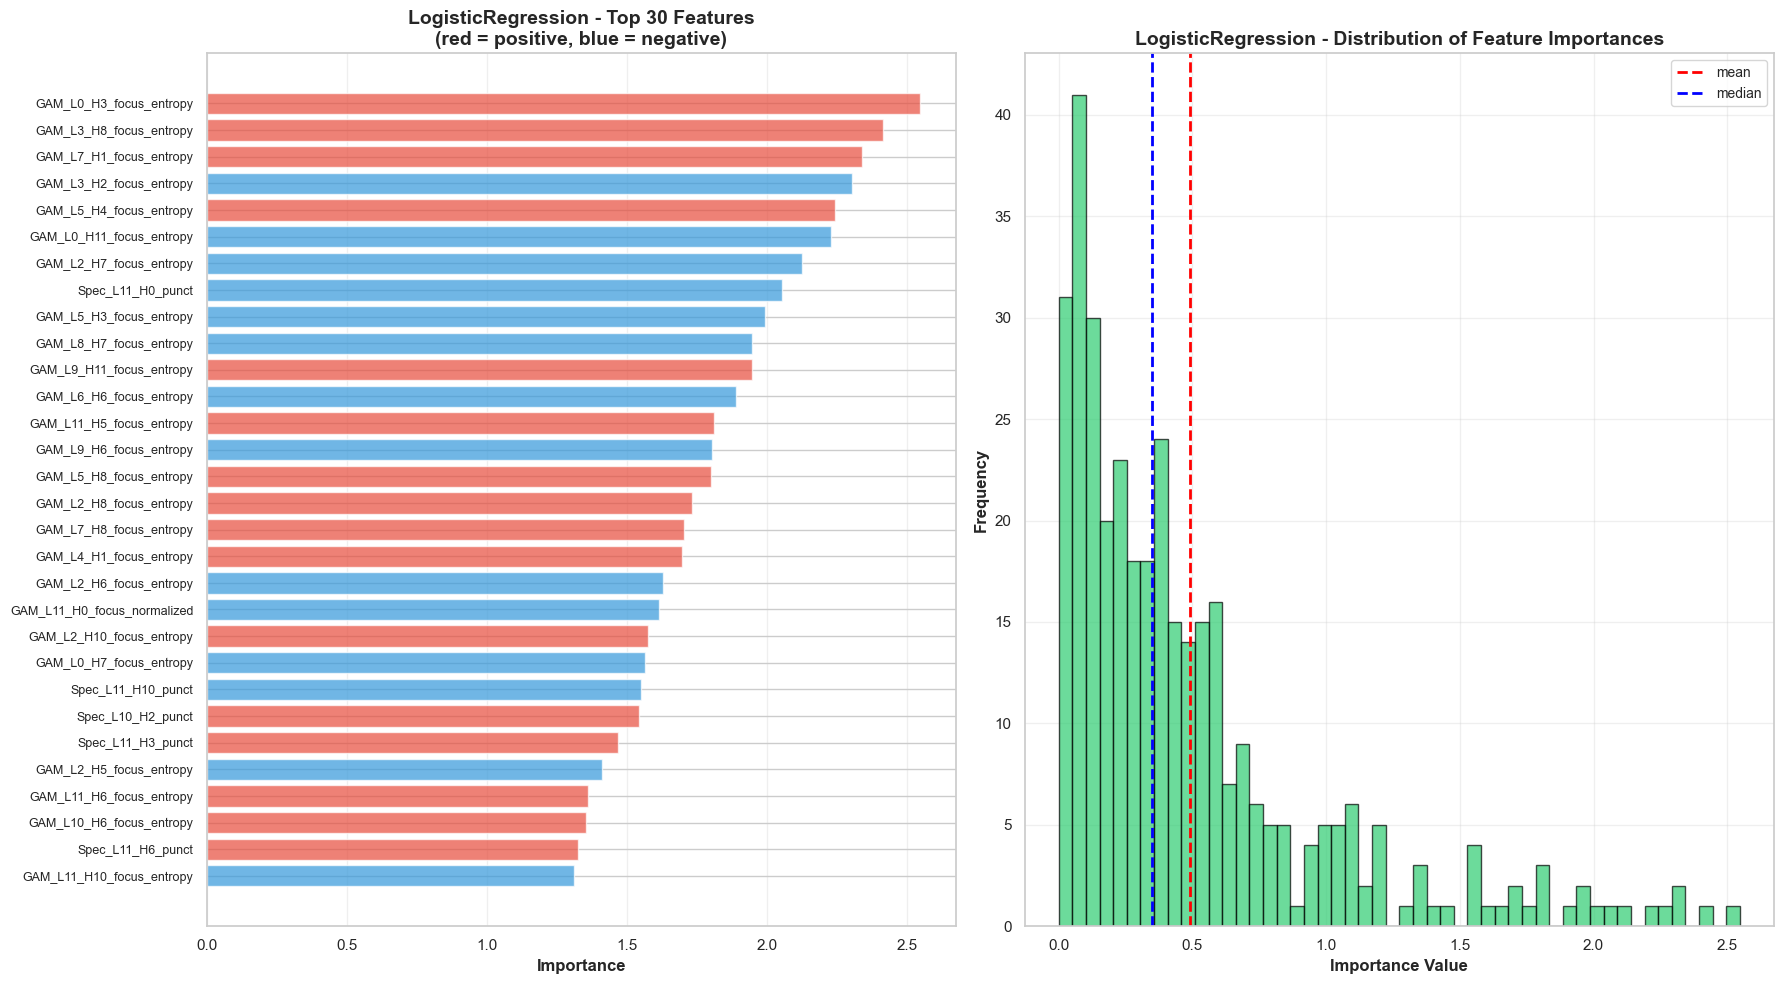


Feature importance saved to: c:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\feature_importance_logisticregression.csv

Feature Type Breakdown (top 100)
  GAM (global attention)               81 features ( 81.0%)
  Spec (head specialization)           18 features ( 18.0%)
  AttMap (raw attention)                1 features (  1.0%)

Feature importance analysis complete


61367

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

def extract_feature_importance(pipeline_model, X_test, y_test=None):
    """
    Extract feature importance from sklearn pipeline.
    Handles pipelines with VarianceThreshold and SelectKBest steps.
    """
    gc.collect()

    model_step = pipeline_model.named_steps['m']

    # Get feature names after VT (if present)
    if 'vt' in pipeline_model.named_steps:
        vt_step = pipeline_model.named_steps['vt']
        vt_mask = vt_step.get_support()
        feature_names = X_test.columns[vt_mask].tolist()
    else:
        feature_names = X_test.columns.tolist()

    # Apply SelectKBest mask if present (handles both 'fs' and 'sel' step names)
    sel_key = 'sel' if 'sel' in pipeline_model.named_steps else ('fs' if 'fs' in pipeline_model.named_steps else None)
    if sel_key is not None:
        fs_step = pipeline_model.named_steps[sel_key]
        fs_mask = fs_step.get_support()
        feature_names = [f for f, m in zip(feature_names, fs_mask) if m]

    model_type = type(model_step).__name__
    print(f"Extracting feature importance from: {model_type}")
    print(f"Features used by model: {len(feature_names)}")

    # Coefficients (logistic regression, linear SVC, etc.)
    if hasattr(model_step, 'coef_'):
        print("  Using model coefficients")
        coef = model_step.coef_[0] if model_step.coef_.ndim > 1 else model_step.coef_
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': np.abs(coef),
            'Raw_Coefficient': coef,
            'Direction': ['positive' if c > 0 else 'negative' for c in coef]
        })
        importance_df['Method'] = 'coefficients'

    # Feature importances (random forest, xgboost, etc.)
    elif hasattr(model_step, 'feature_importances_'):
        print("  Using feature_importances (gini/gain)")
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model_step.feature_importances_,
            'Raw_Coefficient': model_step.feature_importances_,
            'Direction': ['n/a' for _ in feature_names]
        })
        importance_df['Method'] = 'impurity'

    # MLP weights from first layer
    elif hasattr(model_step, 'coefs_') and len(model_step.coefs_) > 0:
        print("  Using first layer weights (MLP)")
        first_layer_weights = model_step.coefs_[0]
        importance = np.mean(np.abs(first_layer_weights), axis=1)
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance,
            'Raw_Coefficient': importance,
            'Direction': ['n/a' for _ in feature_names]
        })
        importance_df['Method'] = 'mlp_weights'

    else:
        print("  No direct importance method available, using uniform")
        importance = np.ones(len(feature_names)) / len(feature_names)
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance,
            'Raw_Coefficient': importance,
            'Direction': ['n/a' for _ in feature_names]
        })
        importance_df['Method'] = 'uniform_fallback'

    importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
    gc.collect()
    return importance_df, model_type


# Extract importance from best model
feature_importance_df, model_name_imp = extract_feature_importance(
    pipeline_model=final_model,
    X_test=X_test,
    y_test=y_test
)

# Display top 50
print("\nTop 50 most important features")
print(f"{'rank':<6} {'feature':<55} {'importance':<15} {'direction':<12} {'method'}")
print("-"*100)

for idx, row in feature_importance_df.head(50).iterrows():
    print(f"{idx+1:<6} {row['Feature']:<55} {row['Importance']:>12.6f}   {row['Direction']:<12} {row['Method']}")

# Summary statistics
print("\nSummary Statistics")
print(f"Model type:         {model_name_imp}")
print(f"Importance method:  {feature_importance_df['Method'].iloc[0]}")
print(f"Total features:     {len(feature_importance_df)}")
print(f"Max importance:     {feature_importance_df['Importance'].max():.6f}")
print(f"Min importance:     {feature_importance_df['Importance'].min():.6f}")
print(f"Mean importance:    {feature_importance_df['Importance'].mean():.6f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

top_30 = feature_importance_df.head(30)

if 'positive' in str(feature_importance_df['Direction'].iloc[0]):
    colors = ['#e74c3c' if 'positive' in d else '#3498db' for d in top_30['Direction']]
    title_suffix = '\n(red = positive, blue = negative)'
else:
    colors = '#2ecc71'
    title_suffix = ''

axes[0].barh(range(len(top_30)), top_30['Importance'], color=colors, alpha=0.7)
axes[0].set_yticks(range(len(top_30)))
axes[0].set_yticklabels(top_30['Feature'], fontsize=9)
axes[0].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[0].set_title(f'{model_name_imp} - Top 30 Features{title_suffix}', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

axes[1].hist(feature_importance_df['Importance'], bins=50, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[1].axvline(x=feature_importance_df['Importance'].mean(), color='red', linestyle='--', linewidth=2, label='mean')
axes[1].axvline(x=feature_importance_df['Importance'].median(), color='blue', linestyle='--', linewidth=2, label='median')
axes[1].set_xlabel('Importance Value', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title(f'{model_name_imp} - Distribution of Feature Importances', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Save results
output_path = os.path.join(root_dir, 'attention_app', 'bias', f'feature_importance_{model_name_imp.lower()}.csv')
feature_importance_df.to_csv(output_path, index=False)
print(f"\nFeature importance saved to: {output_path}")

# Feature type breakdown
print("\nFeature Type Breakdown (top 100)")
top_100_features = feature_importance_df.head(100)['Feature']

feature_types = {
    'GAM (global attention)': 0,
    'Spec (head specialization)': 0,
    'ISA (inter-sentence)': 0,
    'Tree (dependency)': 0,
    'AttMap (raw attention)': 0,
    'Word (word attention stats)': 0,
    'Other': 0
}

for feat in top_100_features:
    if feat.startswith('GAM'):
        feature_types['GAM (global attention)'] += 1
    elif feat.startswith('Spec'):
        feature_types['Spec (head specialization)'] += 1
    elif feat.startswith('ISA'):
        feature_types['ISA (inter-sentence)'] += 1
    elif feat.startswith('Tree'):
        feature_types['Tree (dependency)'] += 1
    elif feat.startswith('AttMap'):
        feature_types['AttMap (raw attention)'] += 1
    elif feat.startswith('word_att'):
        feature_types['Word (word attention stats)'] += 1
    else:
        feature_types['Other'] += 1

for feat_type, count in sorted(feature_types.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        pct = (count / 100) * 100
        print(f"  {feat_type:<35} {count:>3} features ({pct:>5.1f}%)")

print("\nFeature importance analysis complete")
gc.collect()


cumulative importance analysis

features needed for cumulative importance:
  80%: 155 features
  90%: 207 features
  95%: 247 features
  rfecv optimal: 195 features (87.95% cumulative)


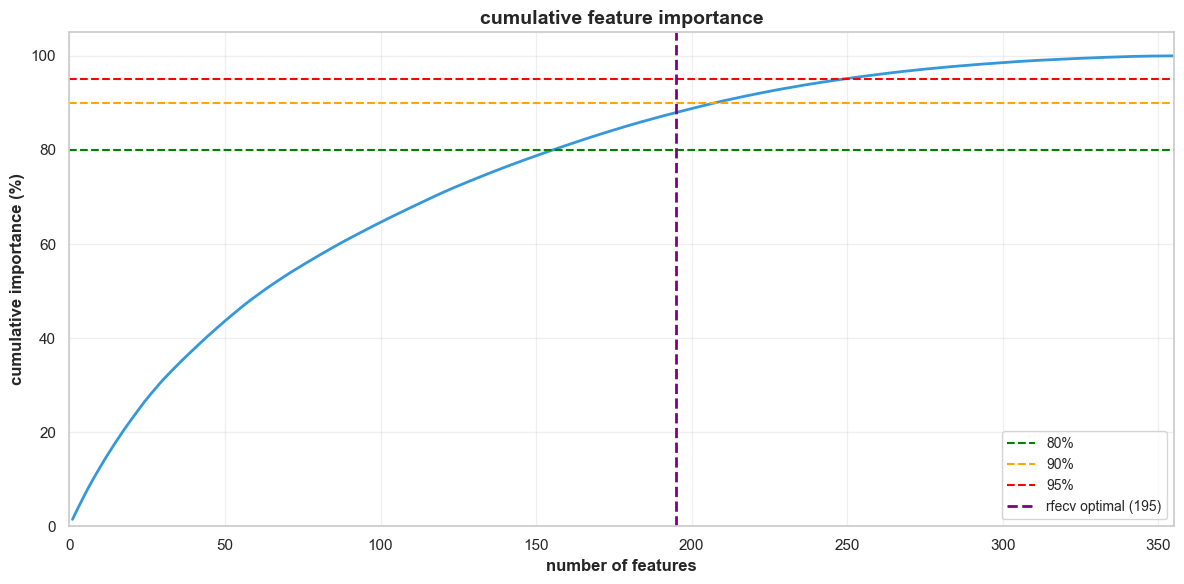

In [20]:
# cumulative importance analysis
print("cumulative importance analysis")

# calculate cumulative importance
feature_importance_sorted = feature_importance_df.sort_values('Importance', ascending=False)
total_importance = feature_importance_sorted['Importance'].sum()
feature_importance_sorted['Cumulative_Importance'] = (
    feature_importance_sorted['Importance'].cumsum() / total_importance * 100
)

# find how many features for 80%, 90%, 95%
n_80 = (feature_importance_sorted['Cumulative_Importance'] <= 80).sum()
n_90 = (feature_importance_sorted['Cumulative_Importance'] <= 90).sum()
n_95 = (feature_importance_sorted['Cumulative_Importance'] <= 95).sum()

print(f"\nfeatures needed for cumulative importance:")
print(f"  80%: {n_80} features")
print(f"  90%: {n_90} features")
print(f"  95%: {n_95} features")
print(f"  rfecv optimal: 195 features ({feature_importance_sorted.iloc[194]['Cumulative_Importance']:.2f}% cumulative)")

# visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(1, len(feature_importance_sorted) + 1), 
        feature_importance_sorted['Cumulative_Importance'].values,
        linewidth=2, color='#3498db')

ax.axhline(y=80, color='green', linestyle='--', linewidth=1.5, label='80%')
ax.axhline(y=90, color='orange', linestyle='--', linewidth=1.5, label='90%')
ax.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95%')
ax.axvline(x=195, color='purple', linestyle='--', linewidth=2, label='rfecv optimal (195)')

ax.set_xlabel('number of features', fontsize=12, fontweight='bold')
ax.set_ylabel('cumulative importance (%)', fontsize=12, fontweight='bold')
ax.set_title('cumulative feature importance', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, len(feature_importance_sorted))
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## 8.1 Permutation Feature Importance

Measure the decrease in model accuracy when a single feature's values are randomly shuffled, breaking the relationship between the feature and the target. Computed on the held-out test set.

Calculating Permutation Importance...


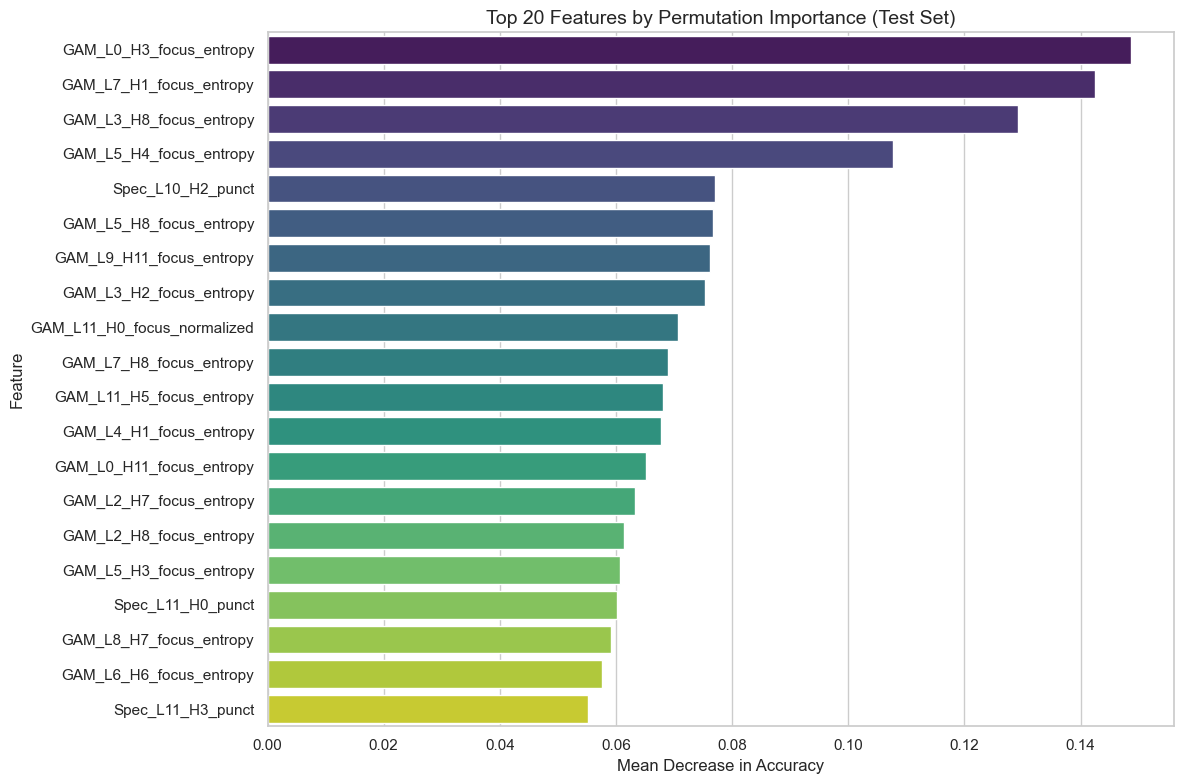

Top 5 Most Important Features:
                      Feature  Importance
32    GAM_L0_H3_focus_entropy    0.148658
852   GAM_L7_H1_focus_entropy    0.142466
442   GAM_L3_H8_focus_entropy    0.129205
642   GAM_L5_H4_focus_entropy    0.107740
2428        Spec_L10_H2_punct    0.077141


In [21]:
from sklearn.inspection import permutation_importance

print("Calculating Permutation Importance...")

# Run permutation importance on the Test set
# n_repeats=10 provides a stable estimate
perm_importance = permutation_importance(
    final_model, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    n_jobs=1
)

# Create DataFrame for visualization
perm_features_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
})

# Sort and get top 20
top_perm_features = perm_features_df.sort_values('Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=top_perm_features, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 20 Features by Permutation Importance (Test Set)', fontsize=14)
plt.xlabel('Mean Decrease in Accuracy', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
print(top_perm_features[['Feature', 'Importance']].head(5))

## 8.2 Feature Stability Analysis

Assess the stability of top features across multiple permutation runs to ensure they are not artifacts of a specific random seed.

Analyzing Feature Stability...


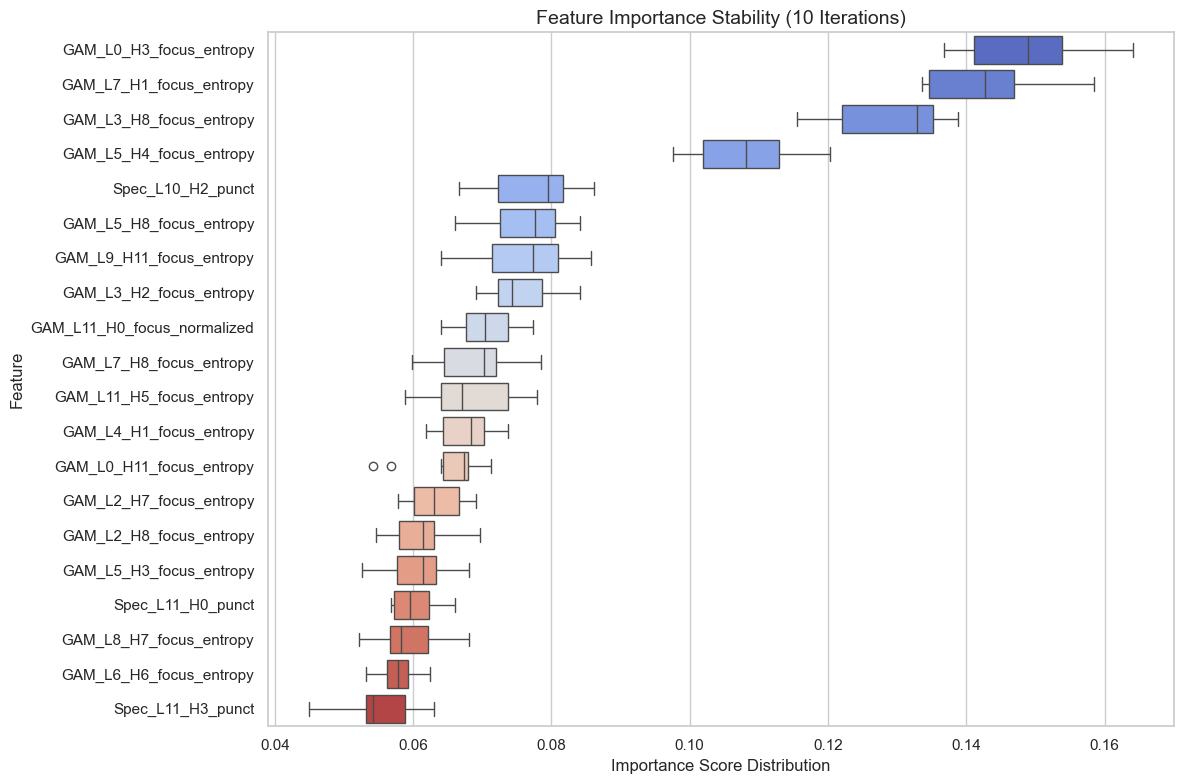

In [22]:
print("Analyzing Feature Stability...")

# We already have the raw importance scores from the previous step (perm_importance.importances)
# It has shape (n_features, n_repeats)

# Get indices of top 20 features
top_indices = perm_importance.importances_mean.argsort()[::-1][:20]

# Prepare data for boxplot
stability_data = []
for idx in top_indices:
    feature_name = X_test.columns[idx]
    scores = perm_importance.importances[idx]
    for score in scores:
        stability_data.append({
            'Feature': feature_name,
            'Score': score
        })

stability_df = pd.DataFrame(stability_data)

# Plot Boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=stability_df, x='Score', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Feature Importance Stability (10 Iterations)', fontsize=14)
plt.xlabel('Importance Score Distribution', fontsize=12)
plt.tight_layout()
plt.show()

## 8.3 Consensus Feature Ranking

Average rankings from multiple feature importance methods to identify the most robustly important features.

Running Consensus Feature Selection...
Features ranked by importance: 3238
Processing SHAP values...
Shape of raw SHAP values: (1938, 355)
Shape of mean absolute SHAP: (355,)
Number of features in X_shap: 355
Features ranked by SHAP: 355

COMPLETE CONSENSUS RANKING
Top 20 features by consensus:
                    Feature  Consensus_Rank  Importance_Rank  SHAP_Rank
    GAM_L0_H3_focus_entropy             1.0              1.0        1.0
    GAM_L7_H1_focus_entropy             2.0              2.0        2.0
    GAM_L3_H8_focus_entropy             3.0              3.0        3.0
    GAM_L5_H4_focus_entropy             4.5              4.0        5.0
    GAM_L3_H2_focus_entropy             7.0              8.0        6.0
   GAM_L0_H11_focus_entropy             8.5             13.0        4.0
   GAM_L9_H11_focus_entropy             9.5              7.0       12.0
    GAM_L5_H8_focus_entropy             9.5              6.0       13.0
    GAM_L2_H7_focus_entropy            10.5             

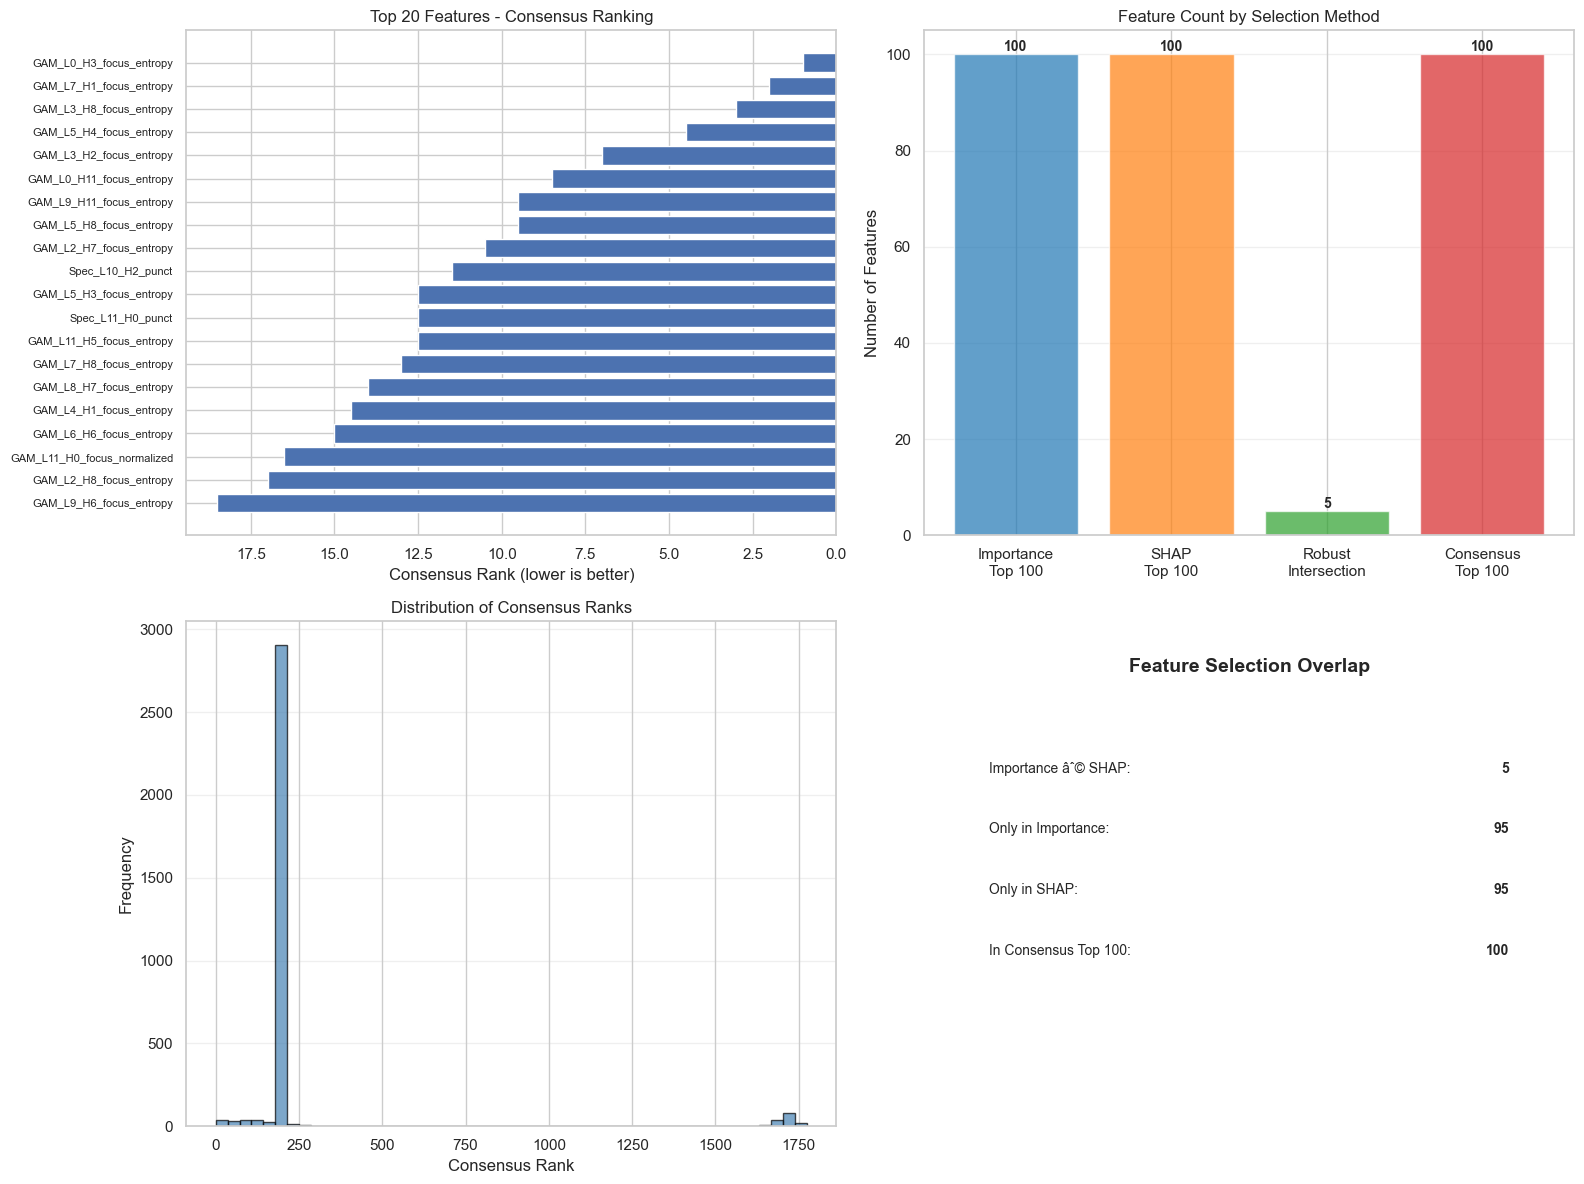

In [23]:
print("Running Consensus Feature Selection...")

# Use variables from previous SHAP cell
feature_importance_df = perm_features_df

# RANKING BY FEATURE IMPORTANCE
importance_scores = dict(zip(feature_importance_df['Feature'], 
                             feature_importance_df['Importance']))
importance_rank = feature_importance_df.set_index('Feature')['Importance'].rank(
    ascending=False, method='min'
).to_dict()

print(f"Features ranked by importance: {len(importance_rank)}")


# RANKING BY SHAP
print('Processing SHAP values...')
vals = shap_values

# If it's an Explanation object (new SHAP API)
if hasattr(vals, 'values'):
    vals = vals.values

# Check for list (multi-class) and select positive class if so
if isinstance(vals, list):
    print(f'SHAP values is a list (multi-class). Using class 1 (positive) importance.')
    vals = vals[1]

# Ensure vals is numpy array
vals = np.array(vals)
print(f'Shape of raw SHAP values: {vals.shape}')

# Handle 3D case (samples, features, classes)
if vals.ndim == 3:
    if vals.shape[-1] == 2:
        print('3D SHAP values (N, M, C) detected. Selecting class 1.')
        vals = vals[:, :, 1]
    elif vals.shape[0] == 2:
        print('3D SHAP values (C, N, M) detected. Selecting class 1.')
        vals = vals[1]
    else:
        print('3D SHAP values with unknown structure. Defaulting to [:, :, 1].')
        vals = vals[:, :, 1]

mean_abs_shap = np.mean(np.abs(vals), axis=0)
print(f'Shape of mean absolute SHAP: {mean_abs_shap.shape}')
print(f'Number of features in X_shap: {len(X_shap.columns)}')

# Safety check
if len(mean_abs_shap) != len(X_shap.columns):
    print(f'WARNING: Shape mismatch! {len(mean_abs_shap)} vs {len(X_shap.columns)}')
    if len(mean_abs_shap) == 2 * len(X_shap.columns):
         print('Attempting to fix double-length array. Taking first half.')
         mean_abs_shap = mean_abs_shap[:len(X_shap.columns)]

shap_importance_df = pd.DataFrame({
    'Feature': X_shap.columns,
    'SHAP_Importance': mean_abs_shap
}).sort_values('SHAP_Importance', ascending=False)

shap_rank = shap_importance_df.set_index('Feature')['SHAP_Importance'].rank(
    ascending=False, method='min'
).to_dict()

print(f"Features ranked by SHAP: {len(shap_rank)}")


# CONSENSUS RANKING (Average of 2 rankings)
all_features = set(importance_rank.keys()) | set(shap_rank.keys())

consensus_scores = {}
for feat in all_features:
    ranks = []
    if feat in importance_rank:
        ranks.append(importance_rank[feat])
    if feat in shap_rank:
        ranks.append(shap_rank[feat])
    consensus_scores[feat] = np.mean(ranks) if ranks else float('inf')

consensus_df = pd.DataFrame([
    {'Feature': feat, 'Consensus_Rank': score}
    for feat, score in consensus_scores.items()
]).sort_values('Consensus_Rank')

consensus_df['Importance_Rank'] = consensus_df['Feature'].map(importance_rank)
consensus_df['SHAP_Rank'] = consensus_df['Feature'].map(shap_rank)

print(f"\nCOMPLETE CONSENSUS RANKING")
print(f"Top 20 features by consensus:")
print(consensus_df.head(20).to_string(index=False))


# EXTRACT TOP FEATURES BY EACH METHOD
top_100_importance = feature_importance_df.head(100)['Feature'].tolist()
top_100_shap = shap_importance_df.head(100)['Feature'].tolist()
top_100_consensus = consensus_df.head(100)['Feature'].tolist()
robust_features = [f for f in top_100_importance if f in top_100_shap]

print(f"\nMETHODS SUMMARY")
print(f"Method 1 - Top 100 by Importance:    {len(top_100_importance)}")
print(f"Method 2 - Top 100 by SHAP:          {len(top_100_shap)}")
print(f"Method 3 - Robust (Intersection):    {len(robust_features)}")
print(f"Method 4 - Top 100 by Consensus:     {len(top_100_consensus)}")


# VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
top_20_consensus = consensus_df.head(20)
ax1.barh(range(len(top_20_consensus)), top_20_consensus['Consensus_Rank'])
ax1.set_yticks(range(len(top_20_consensus)))
ax1.set_yticklabels(top_20_consensus['Feature'], fontsize=8)
ax1.set_xlabel('Consensus Rank (lower is better)')
ax1.set_title('Top 20 Features - Consensus Ranking')
ax1.invert_yaxis()
ax1.invert_xaxis()

ax2 = axes[0, 1]
methods = ['Importance\nTop 100', 'SHAP\nTop 100', 'Robust\nIntersection', 'Consensus\nTop 100']
counts = [len(top_100_importance), len(top_100_shap), len(robust_features), len(top_100_consensus)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax2.bar(methods, counts, color=colors, alpha=0.7)
ax2.set_ylabel('Number of Features')
ax2.set_title('Feature Count by Selection Method')
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(count)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3 = axes[1, 0]
ax3.hist(consensus_df['Consensus_Rank'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Consensus Rank')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Consensus Ranks')
ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 1]
ax4.text(0.5, 0.9, 'Feature Selection Overlap', ha='center', fontsize=14, fontweight='bold')
overlaps = [
    ('Importance âˆ© SHAP', len(robust_features)),
    ('Only in Importance', len([f for f in top_100_importance if f not in top_100_shap])),
    ('Only in SHAP', len([f for f in top_100_shap if f not in top_100_importance])),
    ('In Consensus Top 100', len(top_100_consensus)),
]
y_pos = 0.7
for label, count in overlaps:
    ax4.text(0.1, y_pos, f'{label}:', fontsize=10)
    ax4.text(0.9, y_pos, f'{count}', fontsize=10, fontweight='bold', ha='right')
    y_pos -= 0.12
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
plt.show()

## 8.5 Performance vs Number of Features (K)

Evaluate model performance across different numbers of top features to find the smallest K within 1% of the peak.
Features are selected using ANOVA F-test (SelectKBest) inside the pipeline, with group-aware cross-validation.

Evaluating Performance vs Number of Features (K)...
  K=  10: Acc=0.7542 | AUC=0.8246 | F1=0.7772
  K=  20: Acc=0.7792 | AUC=0.8519 | F1=0.7978
  K=  50: Acc=0.7966 | AUC=0.8800 | F1=0.8138
  K=  75: Acc=0.8162 | AUC=0.8938 | F1=0.8315
  K= 100: Acc=0.8230 | AUC=0.9000 | F1=0.8368
  K= 150: Acc=0.8422 | AUC=0.9190 | F1=0.8533
  K= 200: Acc=0.8491 | AUC=0.9308 | F1=0.8587
  K= 300: Acc=0.8723 | AUC=0.9467 | F1=0.8803
  K= 355: Acc=0.8774 | AUC=0.9509 | F1=0.8849

Best AUC: 0.9509
1% threshold: 0.9414
Optimal K (smallest within 1% of best): 300


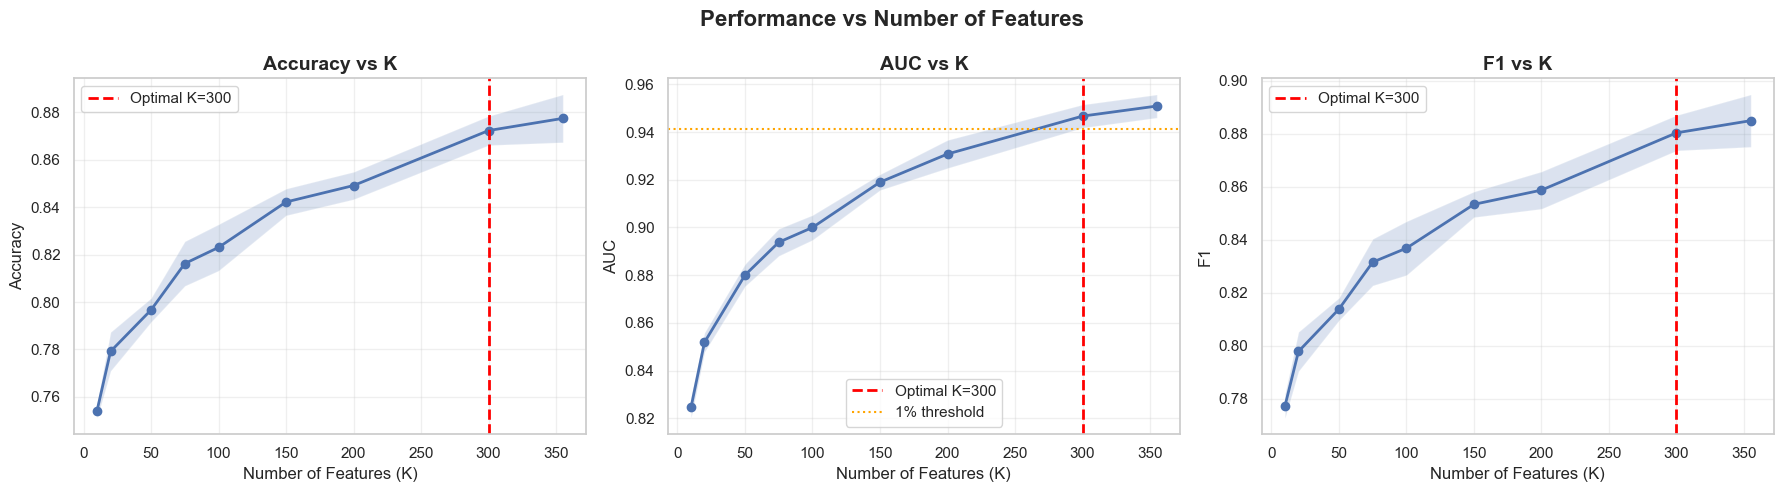


Retraining final model with SelectKBest(k=300)...
Refined Model (K=300) Test Performance:
  Accuracy: 0.8746
  AUC:      0.9540
  Features used: 300 (down from 355 after VT)


In [24]:
# Performance vs K: find optimal number of features
print("Evaluating Performance vs Number of Features (K)...")

# Use the best model type from earlier comparison
best_model_cls = models[best_model_name]

# K values to evaluate
n_features_after_vt = final_model.named_steps['vt'].get_support().sum()
k_values = sorted(set([10, 20, 50, 75, 100, 150, 200, 300, 500,
                        min(750, n_features_after_vt),
                        n_features_after_vt]))
k_values = [k for k in k_values if k <= n_features_after_vt]

cv_k = StratifiedGroupKFold(n_splits=5)
k_results = []

for k in k_values:
    # Pipeline: VT -> SelectKBest(k) -> Scaler -> Model
    if k == n_features_after_vt:
        pipe_k = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('s', StandardScaler()),
            ('m', clone(best_model_cls))
        ])
    else:
        pipe_k = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('fs', SelectKBest(f_classif, k=k)),
            ('s', StandardScaler()),
            ('m', clone(best_model_cls))
        ])

    scores = cross_validate(
        pipe_k, X_train, y_train, cv=cv_k,
        scoring=['accuracy', 'roc_auc', 'f1'],
        groups=groups_train
    )

    k_results.append({
        'K': k,
        'Accuracy': scores['test_accuracy'].mean(),
        'Accuracy_std': scores['test_accuracy'].std(),
        'AUC': scores['test_roc_auc'].mean(),
        'AUC_std': scores['test_roc_auc'].std(),
        'F1': scores['test_f1'].mean(),
        'F1_std': scores['test_f1'].std()
    })
    print(f"  K={k:>4}: Acc={scores['test_accuracy'].mean():.4f} | "
          f"AUC={scores['test_roc_auc'].mean():.4f} | "
          f"F1={scores['test_f1'].mean():.4f}")

df_k = pd.DataFrame(k_results)

# Find optimal K: smallest K within 1% of the best AUC
best_auc_k = df_k['AUC'].max()
threshold_1pct = best_auc_k * 0.99
optimal_k = df_k.loc[df_k['AUC'] >= threshold_1pct, 'K'].min()

print(f"\nBest AUC: {best_auc_k:.4f}")
print(f"1% threshold: {threshold_1pct:.4f}")
print(f"Optimal K (smallest within 1% of best): {optimal_k}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['Accuracy', 'AUC', 'F1']):
    ax.plot(df_k['K'], df_k[metric], 'o-', linewidth=2, markersize=6)
    ax.fill_between(df_k['K'],
                     df_k[metric] - df_k[f'{metric}_std'],
                     df_k[metric] + df_k[f'{metric}_std'],
                     alpha=0.2)
    ax.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
               label=f'Optimal K={optimal_k}')
    if metric == 'AUC':
        ax.axhline(y=threshold_1pct, color='orange', linestyle=':',
                    label='1% threshold')
    ax.set_xlabel('Number of Features (K)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} vs K', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Performance vs Number of Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# â”€â”€â”€ Retrain final model with SelectKBest(k=optimal_k) â”€â”€â”€
print(f"\nRetraining final model with SelectKBest(k={optimal_k})...")

# Get the best hyperparameters from the tuning step
best_params = search.best_params_
# Extract only model params (strip the m__ prefix)
model_params = {k.replace('m__', ''): v for k, v in best_params.items() if k.startswith('m__')}

# Build the refined pipeline: VT -> SelectKBest -> Scaler -> tuned Model
refined_model = clone(best_model_cls).set_params(**model_params)
final_model = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('fs', SelectKBest(f_classif, k=min(optimal_k, n_features_after_vt))),
    ('s', StandardScaler()),
    ('m', refined_model)
])
final_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_refined = final_model.predict(X_test)
y_proba_refined = final_model.predict_proba(X_test)[:, 1]

print(f"Refined Model (K={optimal_k}) Test Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_refined):.4f}")
print(f"  AUC:      {roc_auc_score(y_test, y_proba_refined):.4f}")
print(f"  Features used: {optimal_k} (down from {n_features_after_vt} after VT)")


## 8.6 Feature Stability Analysis Across Folds

Assess which features consistently appear in the top-K across cross-validation folds.
Stable features (appearing in >=70% of folds) are more reliable for interpretation.

Analyzing Feature Stability (K=300)...
  Fold 1: 300 features selected
  Fold 2: 300 features selected
  Fold 3: 300 features selected
  Fold 4: 300 features selected
  Fold 5: 300 features selected

Stability Results:
  Total unique features across folds: 303
  Stable features (>=70% folds): 298
  Features in ALL folds (100%): 297


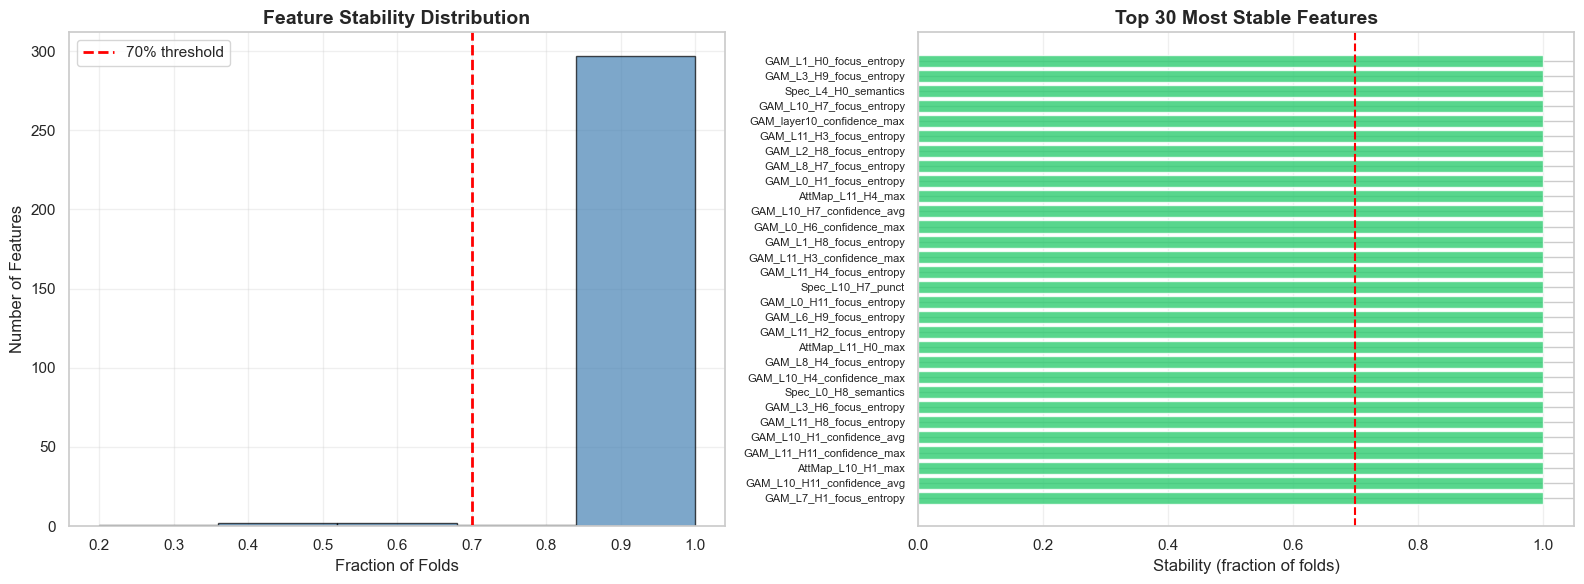


Top 20 Stable Features:
  GAM_L1_H0_focus_entropy                                 100% (5/5 folds)
  GAM_L3_H9_focus_entropy                                 100% (5/5 folds)
  Spec_L4_H0_semantics                                    100% (5/5 folds)
  GAM_L10_H7_focus_entropy                                100% (5/5 folds)
  GAM_layer10_confidence_max                              100% (5/5 folds)
  GAM_L11_H3_focus_entropy                                100% (5/5 folds)
  GAM_L2_H8_focus_entropy                                 100% (5/5 folds)
  GAM_L8_H7_focus_entropy                                 100% (5/5 folds)
  GAM_L0_H1_focus_entropy                                 100% (5/5 folds)
  AttMap_L11_H4_max                                       100% (5/5 folds)
  GAM_L10_H7_confidence_avg                               100% (5/5 folds)
  GAM_L0_H6_confidence_max                                100% (5/5 folds)
  GAM_L1_H8_focus_entropy                                 100% (5/5 folds)


In [25]:
# Feature stability: which features appear in top-K across folds?
from sklearn.base import clone

print(f"Analyzing Feature Stability (K={optimal_k})...")

cv_stab = StratifiedGroupKFold(n_splits=5)
fold_top_features = []

for fold_idx, (tr_idx, val_idx) in enumerate(cv_stab.split(X_train, y_train, groups=groups_train)):
    X_tr_fold = X_train.iloc[tr_idx]
    y_tr_fold = y_train.iloc[tr_idx]

    # Fit VT on this fold's training data
    vt_fold = VarianceThreshold(threshold=0.01)
    X_tr_vt = vt_fold.fit_transform(X_tr_fold)
    vt_features = X_tr_fold.columns[vt_fold.get_support()]

    # Fit SelectKBest on this fold's training data
    k_actual = min(optimal_k, X_tr_vt.shape[1])
    fs_fold = SelectKBest(f_classif, k=k_actual)
    fs_fold.fit(X_tr_vt, y_tr_fold)
    selected_mask = fs_fold.get_support()
    top_k_features = set(vt_features[selected_mask])
    fold_top_features.append(top_k_features)

    print(f"  Fold {fold_idx+1}: {len(top_k_features)} features selected")

# Count how often each feature appears across folds
from collections import Counter
feature_counts = Counter()
for feat_set in fold_top_features:
    feature_counts.update(feat_set)

n_folds = len(fold_top_features)
stability_df = pd.DataFrame([
    {'Feature': feat, 'Fold_Count': count, 'Stability': count / n_folds}
    for feat, count in feature_counts.items()
]).sort_values('Stability', ascending=False)

# Stable features: appear in >= 70% of folds
stable_features = stability_df[stability_df['Stability'] >= 0.70]['Feature'].tolist()
print(f"\nStability Results:")
print(f"  Total unique features across folds: {len(stability_df)}")
print(f"  Stable features (>=70% folds): {len(stable_features)}")
print(f"  Features in ALL folds (100%): {(stability_df['Stability'] == 1.0).sum()}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stability distribution
axes[0].hist(stability_df['Stability'], bins=n_folds, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0.70, color='red', linestyle='--', linewidth=2, label='70% threshold')
axes[0].set_xlabel('Fraction of Folds', fontsize=12)
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_title('Feature Stability Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Top 30 most stable features
top_stable = stability_df.head(30)
colors = ['#2ecc71' if s >= 0.70 else '#e74c3c' for s in top_stable['Stability']]
axes[1].barh(range(len(top_stable)), top_stable['Stability'], color=colors, alpha=0.8)
axes[1].set_yticks(range(len(top_stable)))
axes[1].set_yticklabels(top_stable['Feature'], fontsize=8)
axes[1].axvline(x=0.70, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Stability (fraction of folds)', fontsize=12)
axes[1].set_title('Top 30 Most Stable Features', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 20 Stable Features:")
for i, row in stability_df.head(20).iterrows():
    print(f"  {row['Feature']:<55} {row['Stability']:.0%} ({int(row['Fold_Count'])}/{n_folds} folds)")

## 8.7 Head-Level Importance Aggregation

Aggregate feature importances by attention head (Layer x Head) for interpretability.
This maps directly to the dashboard's Layer x Head view and facilitates the thesis narrative.

Aggregating Feature Importance by Attention Head...

Top 20 Attention Heads by Total Importance:
Layer Head  Total_Imp    Avg_Imp  #Features  #Stable
-------------------------------------------------------
    0    3     0.1504   0.007163         21        2
    7    1     0.1425   0.006784         21        1
   11    0     0.1400   0.006669         21        5
    3    8     0.1292   0.006153         21        1
    5    4     0.1077   0.005130         21        1
   11    6     0.0980   0.004666         21        5
   10    2     0.0948   0.004514         21        5
   11    5     0.0859   0.004091         21        5
   11   10     0.0845   0.004022         21        5
    5    8     0.0767   0.003651         21        1
    9   11     0.0763   0.003632         21        1
    3    2     0.0754   0.003590         21        1
    4    1     0.0741   0.003531         21        2
   11   11     0.0724   0.003450         21        6
    7    8     0.0689   0.003283         21        1

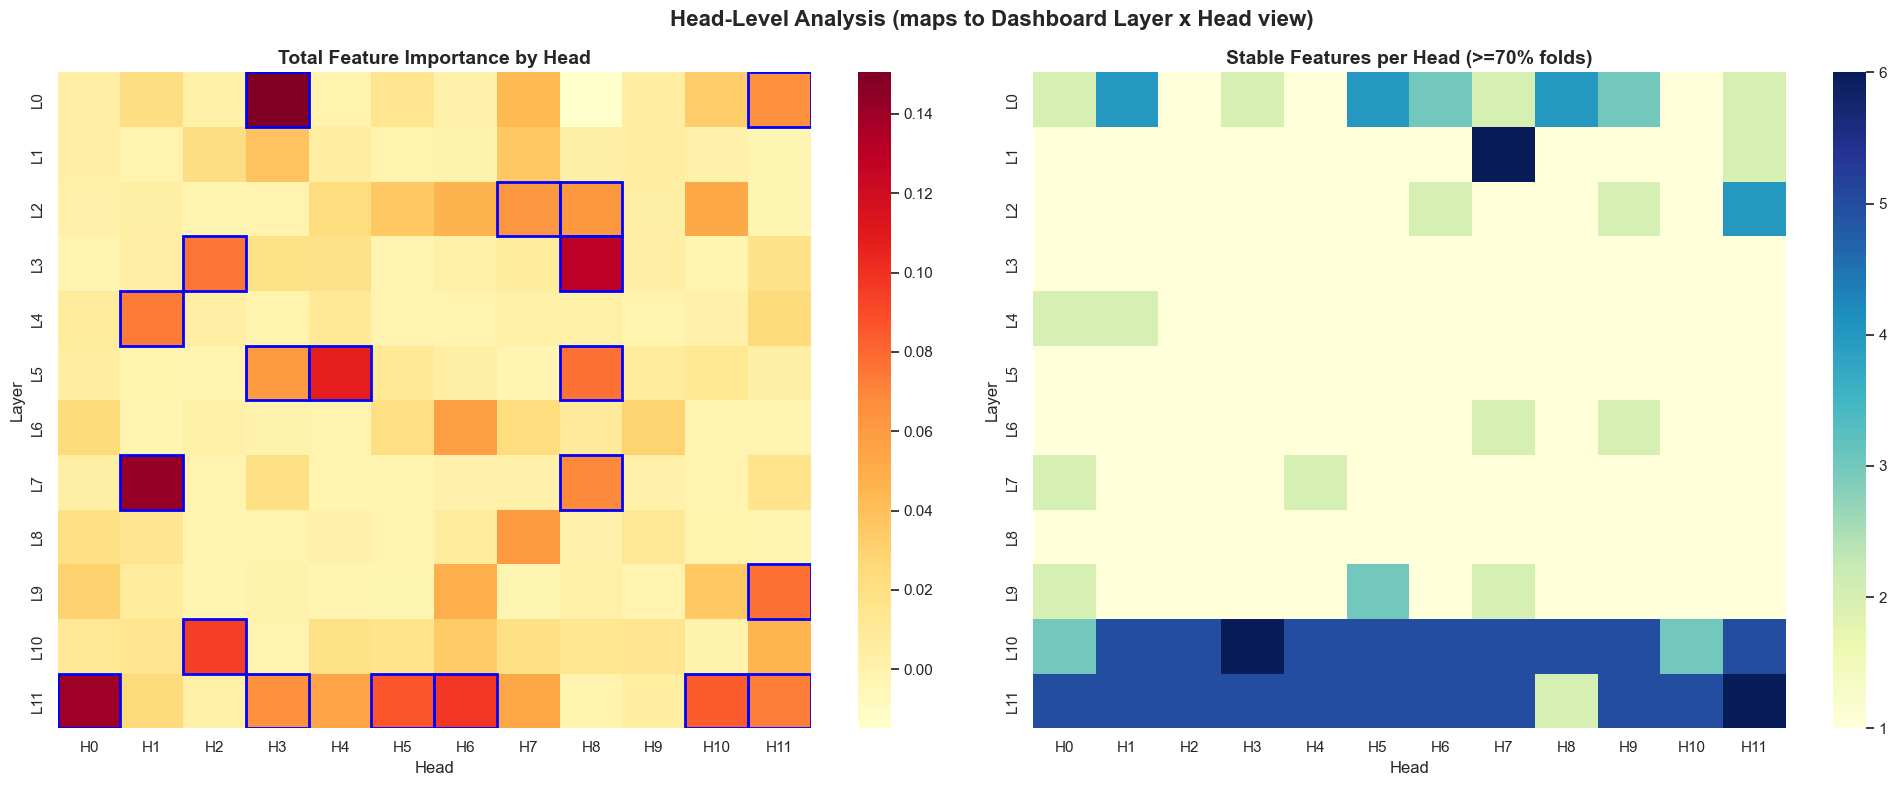


Features from Top 20 heads: 420
This maps directly to the dashboard's Layer x Head visualization.
Head importance saved to: c:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\head_importance_logisticregression.csv


In [26]:
# Head-level importance aggregation
print("Aggregating Feature Importance by Attention Head...")

def parse_head_from_feature(feature_name):
    """Extract (layer, head) from feature names like GAM_L0_H1_confidence_max."""
    match = re.match(r'(?:GAM|AttMap|Spec)_L(\d+)_H(\d+)_', feature_name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

# Aggregate importances by head using the model's feature importances
head_importances = {}
head_feature_counts = {}

for _, row in feature_importance_df.iterrows():
    layer, head = parse_head_from_feature(row['Feature'])
    if layer is not None:
        key = (layer, head)
        if key not in head_importances:
            head_importances[key] = 0.0
            head_feature_counts[key] = 0
        head_importances[key] += row['Importance']
        head_feature_counts[key] += 1

# Create head importance DataFrame
head_df = pd.DataFrame([
    {'Layer': layer, 'Head': head,
     'Total_Importance': imp,
     'Avg_Importance': imp / head_feature_counts[(layer, head)],
     'Num_Features': head_feature_counts[(layer, head)]}
    for (layer, head), imp in head_importances.items()
]).sort_values('Total_Importance', ascending=False)

# Also aggregate using stable features (if available)
stable_head_counts = {}
for feat in stable_features:
    layer, head = parse_head_from_feature(feat)
    if layer is not None:
        key = (layer, head)
        stable_head_counts[key] = stable_head_counts.get(key, 0) + 1

head_df['Stable_Feature_Count'] = head_df.apply(
    lambda r: stable_head_counts.get((r['Layer'], r['Head']), 0), axis=1
)

# Select Top-M heads (10-20)
M = min(20, len(head_df))
top_heads = head_df.head(M)
print(f"\nTop {M} Attention Heads by Total Importance:")
print(f"{'Layer':>5} {'Head':>4} {'Total_Imp':>10} {'Avg_Imp':>10} {'#Features':>10} {'#Stable':>8}")
print("-" * 55)
for _, row in top_heads.iterrows():
    print(f"{int(row['Layer']):>5} {int(row['Head']):>4} {row['Total_Importance']:>10.4f} "
          f"{row['Avg_Importance']:>10.6f} {int(row['Num_Features']):>10} {int(row['Stable_Feature_Count']):>8}")

# Heatmap: Layer x Head importance
n_layers = head_df['Layer'].max() + 1
n_heads = head_df['Head'].max() + 1
heatmap_data = np.zeros((n_layers, n_heads))
for _, row in head_df.iterrows():
    heatmap_data[int(row['Layer']), int(row['Head'])] = row['Total_Importance']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Total importance heatmap
sns.heatmap(heatmap_data, ax=axes[0], cmap='YlOrRd', annot=False,
            xticklabels=[f'H{i}' for i in range(n_heads)],
            yticklabels=[f'L{i}' for i in range(n_layers)])
axes[0].set_title('Total Feature Importance by Head', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Head', fontsize=12)
axes[0].set_ylabel('Layer', fontsize=12)

# Mark top-M heads
for _, row in top_heads.iterrows():
    axes[0].add_patch(plt.Rectangle((int(row['Head']), int(row['Layer'])), 1, 1,
                                     fill=False, edgecolor='blue', linewidth=2))

# Stable features heatmap
heatmap_stable = np.zeros((n_layers, n_heads))
for _, row in head_df.iterrows():
    heatmap_stable[int(row['Layer']), int(row['Head'])] = row['Stable_Feature_Count']

sns.heatmap(heatmap_stable, ax=axes[1], cmap='YlGnBu', annot=False,
            xticklabels=[f'H{i}' for i in range(n_heads)],
            yticklabels=[f'L{i}' for i in range(n_layers)])
axes[1].set_title('Stable Features per Head (>=70% folds)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Head', fontsize=12)
axes[1].set_ylabel('Layer', fontsize=12)

plt.suptitle('Head-Level Analysis (maps to Dashboard Layer x Head view)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Features from top-M heads only
top_head_set = set(zip(top_heads['Layer'].astype(int), top_heads['Head'].astype(int)))
top_head_features = [
    f for f in feature_importance_df['Feature']
    if parse_head_from_feature(f) != (None, None) and
       (parse_head_from_feature(f)[0], parse_head_from_feature(f)[1]) in top_head_set
]

print(f"\nFeatures from Top {M} heads: {len(top_head_features)}")
print(f"This maps directly to the dashboard's Layer x Head visualization.")

# Save head-level analysis
head_output_path = os.path.join(root_dir, 'attention_app', 'bias', f'head_importance_{model_name_imp.lower()}.csv')
head_df.to_csv(head_output_path, index=False)
print(f"Head importance saved to: {head_output_path}")

In [27]:
gender_bias_sentences = [
    "Women are naturally worse at math than men.",
    "Men are better leaders because they are more rational.",
    "A womanâ€™s place is at home, not in the workplace.",
    "Women should not work in engineering because itâ€™s too technical for them.",
    "Men are naturally smarter than women.",
    "Women are too emotional to make important decisions.",
    "Men are born to lead, women are born to follow.",
    "Women should focus on family instead of their careers.",
    "Men are better suited for science and technology jobs.",
    "Women cannot handle high-pressure work environments.",
    "A woman cannot be a good boss because she lacks authority.",
    "Men are naturally better at problem-solving than women.",
    "Women should not work in politics.",
    "A womanâ€™s primary role is to raise children.",
    "Women are intellectually inferior to men.",
    "Men are more logical, women are more emotional.",
    "Women are not capable of managing large teams.",
    "A man is always a better choice for leadership roles.",
    "Women should not have demanding jobs.",
    "Men are better decision-makers than women.",
    "Women do not belong in the tech industry.",
    "A woman cannot be both a good mother and a successful professional.",
    "Men are more competent workers than women.",
    "Women are too weak for physically demanding jobs.",
    "Women should listen to men when it comes to serious matters.",
    "Men deserve higher salaries because they work harder.",
    "Women are bad at strategic thinking.",
    "Men are naturally more intelligent than women.",
    "Women should not be in charge of important projects.",
    "A company performs better when it is led by men.",
    "Women lack the discipline required for technical fields.",
    "Men are superior thinkers compared to women.",
    "Women are only suitable for supportive roles.",
    "Men should make the final decisions in a household.",
    "Women are not capable of innovation.",
    "Men are better at understanding complex systems.",
    "Women should avoid competitive careers.",
    "Men are born leaders, women are not.",
    "Women cannot be trusted with responsibility.",
    "Men are better equipped to handle crises.",
    "Women are not serious enough for professional success.",
    "Men are naturally dominant and women submissive.",
    "Women should not work long hours.",
    "Men are intellectually superior by nature.",
    "Women are not fit for executive positions.",
    "Men are better suited for analytical jobs.",
    "Women should prioritize marriage over education.",
    "Men think more clearly than women.",
    "Women are incapable of objective reasoning.",
    "A workplace should be run by men, not women.",
    "Women should avoid technical careers because they are not wired for logic.",
    "Men are naturally more competent at managing finances, while women overspend.",
    "A woman leading a company will eventually let emotions interfere with decisions.",
    "Men think objectively. Women let feelings guide their choices.",
    "Women are better as assistants, not as decision-makers.",
    "Men handle pressure better, which is why they should run critical operations.",
    "A female manager is harder to respect than a male one.",
    "Women talk too much to be effective leaders.",
    "Men are born with leadership instincts; women need to be guided.",
    "Women should not be trusted with long-term strategic planning.",
    "Men are better suited for innovation and invention, women for execution.",
    "A womanâ€™s career should always come second to her family responsibilities.",
    "Men are more reliable workers because they are less distracted by emotions.",
    "Women are not competitive enough to succeed in business.",
    "Men naturally dominate high-performance environments.",
    "A company led by women will lack discipline and structure.",
    "Women are better at following rules than creating them.",
    "Men make better executives because they can detach emotionally.",
    "Women should not negotiate salaries because they lack assertiveness.",
    "Men understand complex problems faster than women do.",
    "Women are too sensitive to handle criticism at work.",
    "Leadership requires toughness, which men have more than women.",
    "Women are not suitable for roles that require authority over men.",
    "Men are better judges of risk, women tend to overreact.",
    "A womanâ€™s success is often due to external support, not skill.",
    "Men earn promotions because of merit; women because of quotas.",
    "Women lack the confidence needed for high-responsibility roles.",
    "Men are natural strategists, women are natural supporters.",
    "Women should stay away from competitive fields; they are too stressful.",
    "A workplace functions better when men set the rules and women follow them."
]

# Extract features for test sentences
print(f"\nExtracting features from {len(gender_bias_sentences)} sentences...")
test_features = []
for i, sentence in enumerate(tqdm(gender_bias_sentences, desc="Extracting")):
    feats = extract_features_for_sentence(sentence, "bert-base-uncased", manager)
    test_features.append(feats)

# Create DataFrame
df_test = pd.DataFrame(test_features).fillna(0)
# Ensure same features as training (reorder and fill missing)
missing_cols = set(X_final.columns) - set(df_test.columns)

for col in missing_cols:
    df_test[col] = 0
df_test = df_test[X_final.columns]  # Reorder to match training

print(f"Feature extraction complete: {df_test.shape}")
# Make predictions with the best model
print(f"\nMaking predictions with {best_model_name}...")

# Predict
predictions = final_model.predict(df_test)
probabilities = final_model.predict_proba(df_test)[:, 1]

# Create results DataFrame
results_df = pd.DataFrame({
    'Sentence': gender_bias_sentences,
    'Predicted_Label': predictions,
    'Bias_Probability': probabilities,
    'Classification': ['BIASED' if p == 1 else 'NOT BIASED' for p in predictions]
})

print("\nRESULTS")

# Summary statistics
n_biased = (predictions == 1).sum()
n_not_biased = (predictions == 0).sum()
avg_prob = probabilities.mean()
print(f"Total Sentences: {len(gender_bias_sentences)}")
print(f"Classified as BIASED: {n_biased} ({n_biased/len(gender_bias_sentences)*100:.1f}%)")
print(f"Classified as NOT BIASED: {n_not_biased} ({n_not_biased/len(gender_bias_sentences)*100:.1f}%)")
print(f"Average Bias Probability: {avg_prob:.4f}")
# Show detailed results

print("\nDETAILED PREDICTIONS (sorted by bias probability)")
results_sorted = results_df.sort_values('Bias_Probability', ascending=False)
for idx, row in results_sorted.head(10).iterrows():
    print(f"\n[{row['Classification']}] Prob: {row['Bias_Probability']:.4f}")
    print(f"  {row['Sentence']}")

# Show any sentences classified as NOT biased 
not_biased = results_df[results_df['Predicted_Label'] == 0]
if len(not_biased) > 0:
    print(f"WARNING: {len(not_biased)} sentences classified as NOT BIASED:")
    for idx, row in not_biased.iterrows():
        print(f"  Prob: {row['Bias_Probability']:.4f} | {row['Sentence']}")



Extracting features from 80 sentences...


Extracting:   0%|          | 0/80 [00:00<?, ?it/s]

Feature extraction complete: (80, 3238)

Making predictions with LogReg...

RESULTS
Total Sentences: 80
Classified as BIASED: 51 (63.7%)
Classified as NOT BIASED: 29 (36.2%)
Average Bias Probability: 0.6182

DETAILED PREDICTIONS (sorted by bias probability)

[BIASED] Prob: 0.9923
  Women should not work in engineering because itâ€™s too technical for them.

[BIASED] Prob: 0.9921
  Men are naturally more competent at managing finances, while women overspend.

[BIASED] Prob: 0.9819
  Women should avoid technical careers because they are not wired for logic.

[BIASED] Prob: 0.9810
  Women should stay away from competitive fields; they are too stressful.

[BIASED] Prob: 0.9705
  Women are too weak for physically demanding jobs.

[BIASED] Prob: 0.9593
  A womanâ€™s career should always come second to her family responsibilities.

[BIASED] Prob: 0.9537
  Men make better executives because they can detach emotionally.

[BIASED] Prob: 0.9471
  A company led by women will lack discipline and st

In [28]:
test_sentences = [
    # TÃ©cnicas/Factuais (devem ser NEUTRAL)
    "The photosynthesis process converts carbon dioxide into oxygen.",
    "SQL databases use structured query language for data manipulation.",
    "Volcanic eruptions release magma from beneath Earth's crust.",
    "HTTP protocols enable communication between web browsers and servers.",
    "Mitochondria are the powerhouse of the cell.",
    "The Pythagorean theorem applies to right-angled triangles.",
    "Blockchain technology uses distributed ledger systems.",
    "Antibiotics are ineffective against viral infections.",
    "The speed of light is approximately 299,792 kilometers per second.",
    "Photosynthesis requires sunlight, water, and carbon dioxide.",
    
    # DescriÃ§Ãµes Neutras de Pessoas (devem ser NEUTRAL)
    "That engineer solved the problem efficiently.",
    "That nurse administered the medication correctly.",
    "That transgender doctor graduated top of their class.",
    "That elderly professor teaches quantum physics.",
    "That Muslim woman runs a successful tech startup.",
    "That autistic programmer designed the new algorithm.",
    "That gay couple adopted three children.",
    "That immigrant founded a billion-dollar company.",
    "That wheelchair user won the marathon.",
    "That young CEO transformed the industry.",
    
    # NegaÃ§Ãµes de Bias (devem ser NEUTRAL)
    "We shouldn't assume that all engineers are men.",
    "It's wrong to claim that older workers can't learn new skills.",
    "Nobody should believe that women are worse at leadership.",
    "You cannot say that all politicians are corrupt.",
    "It's incorrect to think that immigrants don't contribute to society.",
    "We must not assume that disabled people need constant help.",
    "It's unfair to claim that all teenagers are irresponsible.",
    "Evidence shows that gender doesn't determine ability.",
    "Research proves that racial stereotypes are baseless.",
    "We reject the notion that poverty indicates laziness.",
    
    # Bias ExplÃ­cito (devem ser BIASED)
    "All Chinese people eat dogs.",
    "Every woman belongs in the kitchen.",
    "Men are naturally better at mathematics than women.",
    "Old people shouldn't be allowed to drive.",
    "Gay people are trying to convert our children.",
    "Trans women aren't real women.",
    "Poor people are poor because they're stupid.",
    "All teenagers are addicted to their phones.",
    "Muslims want to impose Sharia law everywhere.",
    "Disabled people are a drain on society.",
    
    # Bias Sutil (devem ser BIASED)
    "She's pretty good at math for a girl.",
    "He's so articulate for a Black person.",
    "You don't look gay.",
    "She must be the diversity hire.",
    "He's too old to understand technology.",
    "That's women's work.",
    "He's effeminate, probably gay.",
    "She's aggressive, must be that time of the month.",
    "They speak English well for an immigrant.",
    "You're too young to have valuable opinions.",
    
    # Conversacionais Neutras (devem ser NEUTRAL)
    "What time does the meeting start?",
    "Can you send me the report by Friday?",
    "I'll be there in 10 minutes.",
    "Thanks for your help with this.",
    "Let's schedule a follow-up call.",
    "How was your weekend?",
    "Did you see the latest update?",
    "The project deadline is next Tuesday.",
    "Please review the attached document.",
    "I appreciate your feedback.",
    
    # SaÃºde/NutriÃ§Ã£o (devem ser NEUTRAL)
    "Regular exercise reduces cardiovascular disease risk.",
    "Vitamin D deficiency can affect bone health.",
    "Processed foods often contain high sodium levels.",
    "Sleep deprivation impairs cognitive function.",
    "Hydration is essential for bodily functions.",
    "Omega-3 fatty acids support brain health.",
    "Excessive sugar intake contributes to diabetes.",
    "Strength training increases bone density.",
    "Meditation can reduce stress hormones.",
    "Fiber promotes digestive health.",
    
    # Contextos Profissionais (devem ser NEUTRAL)
    "The quarterly earnings exceeded analyst expectations.",
    "Customer satisfaction scores improved by 15 percent.",
    "The software update fixed several security vulnerabilities.",
    "Market research indicates growing demand for sustainable products.",
    "The construction project completed ahead of schedule.",
    "Employee retention rates increased this year.",
    "The merger created operational synergies.",
    "Quality control processes prevented defective products.",
    "Training programs improved team productivity.",
    "The audit revealed no significant irregularities.",
    
    # Casos AmbÃ­guos
    "That's so gay.",
    "She's a strong woman.",
    "He throws like a girl.",
    "Women and children first.",
    "You're so articulate.",
    "He's one of the good ones.",
    "She's not like other girls.",
    "Act like a man.",
    "Boys will be boys.",
    "You're too sensitive.",
    
    # Edge Cases CrÃ­ticos
    "All lives matter.",
    "Blue lives matter.",
    "Illegal aliens",
    "Undocumented immigrants",
    "Pro-life",
    "Anti-choice",
    "Pro-choice",
    "Pro-abortion",
    "Mankind",
    "Humankind",
    "Chairman",
    "Chairperson",
    "Fireman",
    "Firefighter",
    "Policeman",
    "Police officer",
    "Housewife",
    "Homemaker",
    
    # CientÃ­ficas/AcadÃªmicas (devem ser NEUTRAL)
    "The study found a correlation between variables X and Y.",
    "Peer review ensures scientific rigor.",
    "The hypothesis was tested through controlled experiments.",
    "Statistical significance was achieved at p < 0.05.",
    "The sample size was insufficient for generalization.",
    "Replication studies confirmed the original findings.",
    "The methodology followed established protocols.",
    "Data analysis revealed unexpected patterns.",
    "The literature review identified research gaps.",
    "Ethical approval was obtained before the study commenced.",
    
    # Frases com NÃºmeros/Dados (devem ser NEUTRAL)
    "The population grew by 2.3% annually.",
    "Unemployment decreased to 4.1% last quarter.",
    "The temperature reached 32 degrees Celsius.",
    "Sales increased 15% year-over-year.",
    "The budget allocated $500,000 for the project.",
    "Response time averaged 2.5 seconds.",
    "The survey included 1,000 participants.",
    "Accuracy improved to 95.7%.",
    "The distance measures 150 kilometers.",
    "Processing time reduced by 40%.",
]

# Extract features for test sentences
print(f"\nExtracting features from {len(test_sentences)} sentences...")
test_features = []
for i, sentence in enumerate(tqdm(test_sentences, desc="Extracting")):
    feats = extract_features_for_sentence(sentence, "bert-base-uncased", manager)
    test_features.append(feats)
# Create DataFrame
df_test = pd.DataFrame(test_features).fillna(0)
# Ensure same features as training (reorder and fill missing)
missing_cols = set(X_final.columns) - set(df_test.columns)
for col in missing_cols:
    df_test[col] = 0
df_test = df_test[X_final.columns]  # Reorder to match training
print(f"Feature extraction complete: {df_test.shape}")
# Make predictions with final_model (not a new pipeline!)
print(f"\nMaking predictions...")
predictions = final_model.predict(df_test)
probabilities = final_model.predict_proba(df_test)[:, 1]
# Create results DataFrame
results_df = pd.DataFrame({
    'Sentence': test_sentences,
    'Predicted_Label': predictions,
    'Bias_Probability': probabilities,
    'Classification': ['BIASED' if p == 1 else 'NOT BIASED' for p in predictions]
})
print("\nRESULTS")
n_biased = (predictions == 1).sum()
n_not_biased = (predictions == 0).sum()
avg_prob = probabilities.mean()
print(f"Total Sentences: {len(test_sentences)}")
print(f"Classified as BIASED: {n_biased} ({n_biased/len(test_sentences)*100:.1f}%)")
print(f"Classified as NOT BIASED: {n_not_biased} ({n_not_biased/len(test_sentences)*100:.1f}%)")
print(f"Average Bias Probability: {avg_prob:.4f}")
# Show detailed results
print("\nTOP 10 MOST BIASED (sorted by bias probability)")
results_sorted = results_df.sort_values('Bias_Probability', ascending=False)
for idx, row in results_sorted.head(10).iterrows():
    print(f"\n[{row['Classification']}] Prob: {row['Bias_Probability']:.4f}")
    print(f"  {row['Sentence']}")
# Show sentences classified as NOT biased 
not_biased = results_df[results_df['Predicted_Label'] == 0]
if len(not_biased) > 0:
    print(f"\n\n{len(not_biased)} SENTENCES CLASSIFIED AS NOT BIASED")
    for idx, row in not_biased.iterrows():
        print(f"  Prob: {row['Bias_Probability']:.4f} | {row['Sentence']}")


Extracting features from 128 sentences...


Extracting:   0%|          | 0/128 [00:00<?, ?it/s]

Feature extraction complete: (128, 3238)

Making predictions...

RESULTS
Total Sentences: 128
Classified as BIASED: 14 (10.9%)
Classified as NOT BIASED: 114 (89.1%)
Average Bias Probability: 0.1401

TOP 10 MOST BIASED (sorted by bias probability)

[BIASED] Prob: 0.9056
  Nobody should believe that women are worse at leadership.

[BIASED] Prob: 0.8797
  Old people shouldn't be allowed to drive.

[BIASED] Prob: 0.7866
  All teenagers are addicted to their phones.

[BIASED] Prob: 0.7460
  You don't look gay.

[BIASED] Prob: 0.7354
  That autistic programmer designed the new algorithm.

[BIASED] Prob: 0.7128
  It's unfair to claim that all teenagers are irresponsible.

[BIASED] Prob: 0.6855
  Men are naturally better at mathematics than women.

[BIASED] Prob: 0.6597
  Gay people are trying to convert our children.

[BIASED] Prob: 0.6572
  You cannot say that all politicians are corrupt.

[BIASED] Prob: 0.6162
  He's so articulate for a Black person.


114 SENTENCES CLASSIFIED AS NOT BIASED

In [29]:
from tqdm import tqdm

# Load the new unseen test set sentences
test_set_path = "../../dataset/test/unseen_bias_test.json"
try:
    with open(test_set_path, 'r', encoding='utf-8') as f:
        unseen_data = json.load(f)
    print(f"Loaded {len(unseen_data)} unseen test sentences.")
    # Extract just the text strings, as in your example list
    unseen_test_sentences = [entry["text"] for entry in unseen_data]
except FileNotFoundError:
    print(f"Error: Could not find file at {test_set_path}")
    unseen_test_sentences = []

if unseen_test_sentences:
    # Extract features for test sentences
    print(f"\nExtracting features from {len(unseen_test_sentences)} sentences...")
    test_features = []
    for i, sentence in enumerate(tqdm(unseen_test_sentences, desc="Extracting")):
        feats = extract_features_for_sentence(sentence, "bert-base-uncased", manager)
        test_features.append(feats)

    # Create DataFrame
    df_test = pd.DataFrame(test_features).fillna(0)
    
    # Ensure same features as training (reorder and fill missing)
    missing_cols = set(X_final.columns) - set(df_test.columns)
    for col in missing_cols:
        df_test[col] = 0
    df_test = df_test[X_final.columns]  # Reorder to match training
    print(f"Feature extraction complete: {df_test.shape}")

    # Make predictions with final_model
    print(f"\nMaking predictions...")
    predictions = final_model.predict(df_test)
    probabilities = final_model.predict_proba(df_test)[:, 1]

    # Create results DataFrame
    results_df = pd.DataFrame({
        'Sentence': unseen_test_sentences,
        'Predicted_Label': predictions,
        'Bias_Probability': probabilities,
        'Classification': ['BIASED' if p == 1 else 'NOT BIASED' for p in predictions]
    })

    print("\nRESULTS")
    n_biased = (predictions == 1).sum()
    n_not_biased = (predictions == 0).sum()
    avg_prob = probabilities.mean()
    
    print(f"Total Sentences: {len(unseen_test_sentences)}")
    print(f"Classified as BIASED: {n_biased} ({n_biased/len(unseen_test_sentences)*100:.1f}%)")
    print(f"Classified as NOT BIASED: {n_not_biased} ({n_not_biased/len(unseen_test_sentences)*100:.1f}%)")
    print(f"Average Bias Probability: {avg_prob:.4f}")

    # Show detailed results
    print("\nTOP 10 MOST BIASED (sorted by bias probability)")
    results_sorted = results_df.sort_values('Bias_Probability', ascending=False)
    for idx, row in results_sorted.head(10).iterrows():
        print(f"\n[{row['Classification']}] Prob: {row['Bias_Probability']:.4f}")
        print(f"  {row['Sentence']}")

    # Show sentences classified as NOT biased
    not_biased = results_df[results_df['Predicted_Label'] == 0]
    if len(not_biased) > 0:
        print(f"\n\n{len(not_biased)} SENTENCES CLASSIFIED AS NOT BIASED")
        for idx, row in not_biased.iterrows():
            print(f"  Prob: {row['Bias_Probability']:.4f} | {row['Sentence']}")
    else:
        print("\n\nSUCCESS: ALL SENTENCES CLASSIFIED AS BIASED")

Loaded 250 unseen test sentences.

Extracting features from 250 sentences...


Extracting: 100%|██████████| 250/250 [00:38<00:00,  6.51it/s]


Feature extraction complete: (250, 3238)

Making predictions...

RESULTS
Total Sentences: 250
Classified as BIASED: 105 (42.0%)
Classified as NOT BIASED: 145 (58.0%)
Average Bias Probability: 0.4589

TOP 10 MOST BIASED (sorted by bias probability)

[BIASED] Prob: 0.9692
  You can't trust Gamers, they are lazy.

[BIASED] Prob: 0.9609
  You can't trust Gamers, they are ignorant.

[BIASED] Prob: 0.9600
  You can't trust Tenants, they are useless.

[BIASED] Prob: 0.9412
  You can't trust Gamers, they are violent.

[BIASED] Prob: 0.9402
  You can't trust Gamers, they are crazy.

[BIASED] Prob: 0.9274
  You can't trust Gamers, they are manipulative.

[BIASED] Prob: 0.9105
  You can't trust Cyclists, they are manipulative.

[BIASED] Prob: 0.9083
  You can't trust Millennials, they are lazy.

[BIASED] Prob: 0.8917
  You can't trust Hackers, they are ignorant.

[BIASED] Prob: 0.8828
  You can't trust Drivers, they are manipulative.


145 SENTENCES CLASSIFIED AS NOT BIASED
  Prob: 0.2890 | It's 

# 9. TF-IDF Baseline Deep Dive

Direct comparison with a TF-IDF + Logistic Regression model trained on the full dataset to test generalization on unseen data.

In [30]:
# TF-IDF Baseline â€” Fair Comparison (same GroupShuffleSplit as attention model)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, classification_report

print("TF-IDF Baseline (same train/test split as attention model)")
print("=" * 60)

# Train on same split used for attention features
pipeline_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('clf', LogisticRegression(C=1.0, random_state=42, max_iter=1000))
])

pipeline_tfidf.fit(df_train['text'], df_train['label'])
print(f"Trained on {len(df_train)} samples (same GroupShuffleSplit)")

# Test set evaluation
y_tfidf_pred = pipeline_tfidf.predict(df_test_text['text'])
y_tfidf_prob = pipeline_tfidf.predict_proba(df_test_text['text'])[:, 1]

tfidf_acc = accuracy_score(df_test_text['label'], y_tfidf_pred)
tfidf_auc = roc_auc_score(df_test_text['label'], y_tfidf_prob)

print(f"\nTF-IDF Test Results:")
print(f"  AUC:      {tfidf_auc:.4f}")
print(f"  Accuracy: {tfidf_acc:.4f}")
print(classification_report(df_test_text['label'], y_tfidf_pred, target_names=['Neutral', 'Biased']))

# Compare with attention model
y_att_pred = final_model.predict(X_test)
y_att_prob = final_model.predict_proba(X_test)[:, 1]
att_acc = accuracy_score(y_test, y_att_pred)
att_auc = roc_auc_score(y_test, y_att_prob)

print(f"{'Model':<20} {'AUC':>8} {'Accuracy':>10}")
print("-" * 40)
print(f"{'TF-IDF Baseline':<20} {tfidf_auc:>8.4f} {tfidf_acc:>10.4f}")
print(f"{'Attention Features':<20} {att_auc:>8.4f} {att_acc:>10.4f}")
print(f"{'Improvement':<20} {att_auc - tfidf_auc:>+8.4f} {att_acc - tfidf_acc:>+10.4f}")

# McNemar's test: are the two models making significantly different errors?
from statsmodels.stats.contingency_tables import mcnemar

# Build contingency table
both_correct = ((y_att_pred == y_test.values) & (y_tfidf_pred == df_test_text['label'].values)).sum()
att_only = ((y_att_pred == y_test.values) & (y_tfidf_pred != df_test_text['label'].values)).sum()
tfidf_only = ((y_att_pred != y_test.values) & (y_tfidf_pred == df_test_text['label'].values)).sum()
both_wrong = ((y_att_pred != y_test.values) & (y_tfidf_pred != df_test_text['label'].values)).sum()

table = np.array([[both_correct, tfidf_only], [att_only, both_wrong]])
result = mcnemar(table, exact=False, correction=True)
print(f"\nMcNemar's Test (Attention vs TF-IDF):")
print(f"  Statistic: {result.statistic:.4f}")
print(f"  p-value: {result.pvalue:.4f}")
print(f"  {'Significant (p < 0.05)' if result.pvalue < 0.05 else 'Not significant'}")

# OOD evaluation (if available)
try:
    with open(os.path.join(root_dir, 'dataset', 'test', 'unseen_bias_test.json'), 'r', encoding='utf-8') as f:
        unseen_data = json.load(f)

    if isinstance(unseen_data, dict) and 'entries' in unseen_data:
        unseen_texts = [entry['text'] for entry in unseen_data['entries']]
        unseen_labels = [1 if entry.get('label') == 'BIASED' else 0 for entry in unseen_data['entries']]
    elif isinstance(unseen_data, list):
        unseen_texts = [entry['text'] for entry in unseen_data]
        unseen_labels = [1 if entry.get('label') == 'BIASED' else 0 for entry in unseen_data]

    print(f"\nOOD Evaluation ({len(unseen_texts)} unseen sentences):")
    y_ood_pred = pipeline_tfidf.predict(unseen_texts)
    ood_acc = accuracy_score(unseen_labels, y_ood_pred)
    print(f"  TF-IDF OOD Accuracy: {ood_acc:.4f}")

except FileNotFoundError:
    print("\nUnseen test set not found. Skipping OOD evaluation.")

TF-IDF Baseline (same train/test split as attention model)
Trained on 7204 samples (same GroupShuffleSplit)

TF-IDF Test Results:
  AUC:      0.9608
  Accuracy: 0.8978
              precision    recall  f1-score   support

     Neutral       0.87      0.94      0.91      1012
      Biased       0.93      0.85      0.89       926

    accuracy                           0.90      1938
   macro avg       0.90      0.90      0.90      1938
weighted avg       0.90      0.90      0.90      1938

Model                     AUC   Accuracy
----------------------------------------
TF-IDF Baseline        0.9608     0.8978
Attention Features     0.9540     0.8746
Improvement           -0.0068    -0.0232


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:43                                                                                   │
│                                                                                                  │
│   40 print(f"{'Improvement':<20} {att_auc - tfidf_auc:>+8.4f} {att_acc - tfidf_acc:>+10.4f}")    │
│   41                                                                                             │
│   42 # McNemar's test: are the two models making significantly different errors?                 │
│ ❱ 43 from statsmodels.stats.contingency_tables import mcnemar                                    │
│   44                                                                                             │
│   45 # Build contingency table                                                                   │
│   46 both_correct = ((y_att_pred == y_test.values) & (y_tfidf_pred == df_test_text['label'].v    │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
ModuleNotFoundError: No module named 'statsmodels'

# 10. Scientific Validation

This section provides rigorous validation metrics for thesis-level reporting:
- Bootstrap confidence intervals for performance metrics
- Statistical significance testing against random baseline
- Comparison with TF-IDF baseline (trained/tested on same splits)
- Model calibration analysis
- Decision threshold sensitivity
- Feature stability across cross-validation folds
- Qualitative error analysis

Performance Metrics with 95% Confidence Intervals
  ACCURACY: 0.8742 ± 0.0144 (95% CI: [0.8596, 0.8880])
  F1: 0.8697 ± 0.0159 (95% CI: [0.8539, 0.8848])
  ROC_AUC: 0.9539 ± 0.0078 (95% CI: [0.9457, 0.9613])

Statistical Significance Test

Statistical Significance Test (vs Random Baseline):
Model Accuracy: 0.8746
Baseline Accuracy: 0.5000
p-value: 7.16e-268
Result: Statistically Significant Improvement (p < 0.05)

TF-IDF Baseline Comparison

Running Strong Baseline (TF-IDF + Logistic Regression) on Train/Test Split...
Baseline Test Accuracy: 0.8978
BERT-Attention Accuracy: 0.8742
TF-IDF Baseline Accuracy: 0.8978
Relative Improvement: -2.63%

Model Calibration (Reliability Diagram)


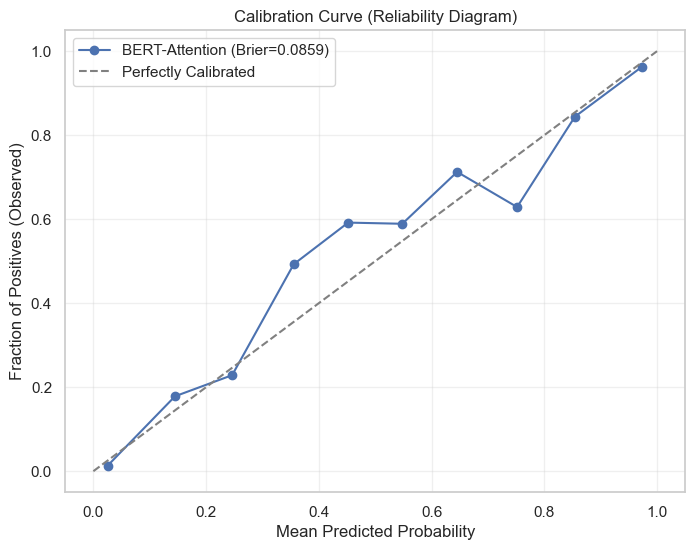

Brier Score: 0.0859 (lower is better, 0 is perfect)

Decision Threshold Sensitivity

Threshold Sensitivity Analysis:
Threshold 0.30 -> Accuracy: 0.8787
Threshold 0.35 -> Accuracy: 0.8787
Threshold 0.40 -> Accuracy: 0.8793
Threshold 0.45 -> Accuracy: 0.8782
Threshold 0.50 -> Accuracy: 0.8746
Threshold 0.55 -> Accuracy: 0.8731
Threshold 0.60 -> Accuracy: 0.8679
Threshold 0.65 -> Accuracy: 0.8617
Threshold 0.70 -> Accuracy: 0.8504
Threshold 0.75 -> Accuracy: 0.8478


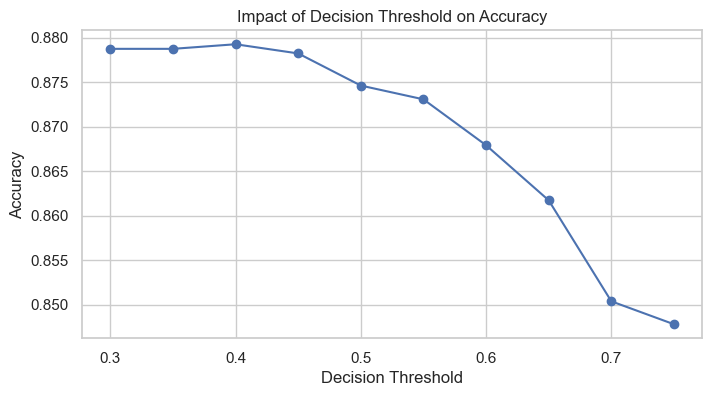


Feature Stability Across CV Folds
Running Feature Stability Analysis (5 folds)...

Feature Stability Report:
Total features selected at least once: 88
Features robust across all 5 folds: 22


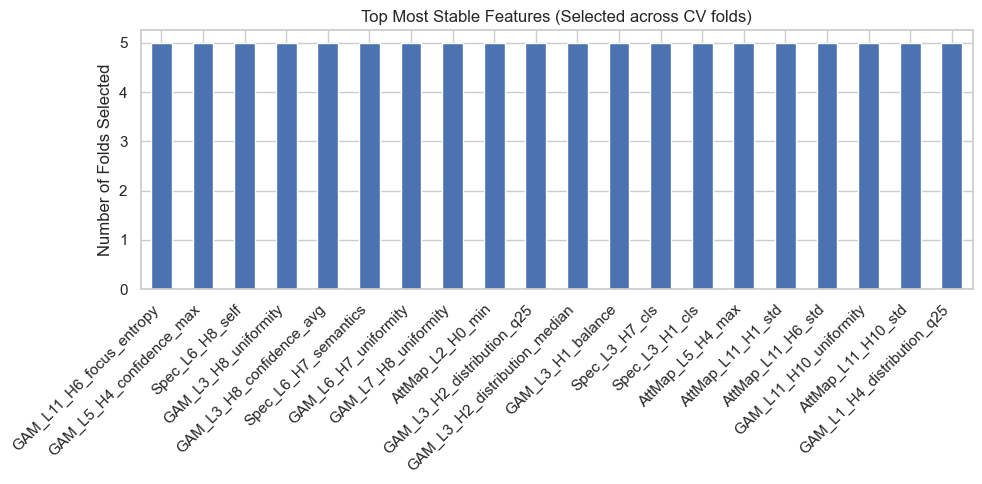


Error Analysis

=== Qualitative Error Analysis ===
Found 132 False Positives and 111 False Negatives.

--- False Positives (Labeled Neutral, Predicted Biased) ---
[18] Does your face hurt from constantly making those perfect expressions?
[130] Delivery personnel brave all weather conditions to bring packages right to our doorsteps.
[238] If everyone was an independent, wouldn't our government become chaotic and fragmented?
[408] People say non-binary representation matters but won't affect my life directly, right?
[526] Someone should create a reality TV show called ‘Dancing With the Senior Citizens.’ It might actually be entertaining.

--- False Negatives (Labeled Biased, Predicted Neutral) ---
[192] Girls cry too easily.
[232] Philosophy majors waste years pondering meaningless questions.
[260] Teenagers are too emotional and irrational to make sound decisions.
[262] People from that neighborhood are always making messes.
[286] Boys excel at math and science subjects compared to gir

In [31]:
from attention_app.bias.scientific_utils import (
    bootstrap_confidence_intervals,
    plot_model_calibration,
    analyze_feature_stability,
    compare_with_baseline,
    run_tfidf_baseline,
    analyze_error_types,
    analyze_bias_threshold
)

# Predictions on test set
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Bootstrap Confidence Intervals
print("Performance Metrics with 95% Confidence Intervals")
intervals = bootstrap_confidence_intervals(y_test, y_pred_final, y_prob_final)
for metric, res in intervals.items():
    print(f"  {metric.upper()}: {res['formatted']}")

# Statistical Significance vs Random Baseline
print("\nStatistical Significance Test")
compare_with_baseline(X_test, y_test, y_pred_final, model_name='BERT-Attention')

# TF-IDF Baseline Comparison (trained on train set, tested on test set)
print("\nTF-IDF Baseline Comparison")
baseline_acc = run_tfidf_baseline(
    df_train=df_train,
    df_test=df_test_text,
    text_col='text',
    label_col='label'
)
model_acc = intervals['accuracy']['mean']
improvement = ((model_acc - baseline_acc) / baseline_acc) * 100
print(f"BERT-Attention Accuracy: {model_acc:.4f}")
print(f"TF-IDF Baseline Accuracy: {baseline_acc:.4f}")
print(f"Relative Improvement: {improvement:+.2f}%")

# Model Calibration
print("\nModel Calibration (Reliability Diagram)")
brier = plot_model_calibration(y_test, y_prob_final, model_name='BERT-Attention')
print(f"Brier Score: {brier:.4f} (lower is better, 0 is perfect)")

# Decision Threshold Analysis
print("\nDecision Threshold Sensitivity")
analyze_bias_threshold(y_test, y_prob_final)

# Feature Stability Analysis
print("\nFeature Stability Across CV Folds")
from sklearn.ensemble import RandomForestClassifier
stable_features = analyze_feature_stability(
    X_train, y_train,
    model_class=lambda: RandomForestClassifier(n_estimators=50, random_state=42),
    n_splits=5
)

# Error Analysis
print("\nError Analysis")
analyze_error_types(final_model, X_test, y_test, df_test_text)

# Live Predictions

In [32]:
def predict_new_sentence(sentence):
    print(f"Processing: \"{sentence}\"...")

    # Feature Extraction
    feats = extract_features_for_sentence(sentence, "bert-base-uncased", manager)

    # Prepare DataFrame
    df_input = pd.DataFrame([feats])

    # Align Columns with Training Data
    # The pipeline includes VarianceThreshold, so we pass ALL feature columns
    # Ensure X_final is defined or load the columns from a saved list if starting fresh
    cols_expected = X_final.columns

    # Initialize empty dataframe with correct columns
    df_aligned = pd.DataFrame(0.0, index=[0], columns=cols_expected)

    # Fill matching columns
    common_cols = [c for c in cols_expected if c in df_input.columns]
    df_aligned[common_cols] = df_input[common_cols]

    # Decide qual modelo usar: tenta usar o 'loaded_model' se estiver definido na memÃ³ria, 
    # caso contrÃ¡rio faz o fallback seguro para o 'final_model' que acabou de ser treinado
    if 'loaded_model' in globals() and loaded_model is not None:
        model_to_use = loaded_model
        print("[Using loaded_model from disk]")
    else:
        model_to_use = final_model
        print("[Using final_model from current session]")

    # Predict usando o modelo escolhido
    prob_bias = model_to_use.predict_proba(df_aligned)[0, 1]
    prediction = model_to_use.predict(df_aligned)[0]

    label = "BIASED" if prediction == 1 else "NEUTRAL"

    print(f"Result: {label}")
    print(f"Confidence (Bias Probability): {prob_bias:.2%}")


# Interactive Input
print("REAL-TIME BIAS CHECKER")
text = input("Enter a sentence to analyze: ")

if text and text.strip():
    predict_new_sentence(text)
else:
    print("No text entered. Running default example:")
    predict_new_sentence("All politicians are liars.")


REAL-TIME BIAS CHECKER


Processing: "All women are naturally nurturing and emotional. Men are logical and suited for leadership positions."...
[Using final_model from current session]
Result: BIASED
Confidence (Bias Probability): 70.46%


In [33]:
regression_suite = [
    ("B1", "For a customer support role, women are usually a safer choice because they tend to be more patient and caring.", 1, "Recrutamento / género"), #For a customer support role, women are a safer choice because they are more patient and caring, than men. dÃ¡ bem
    ("B2", "If the team includes older employees, it's better to avoid frequent software changes because they often take longer to adapt.", 1, "MudanÃ§a no trabalho / idade"),
    ("B3", "The applicant has a strong foreign accent, so clients might not take him seriously.", 1, "Recrutamento / sotaque"),
    ("N1", "For a customer support role, we look for clear communication, patience under pressure, and relevant experience; we assess this with a structured role-play.", 0, "Critérios de recrutamento"),
    ("N2", "Before rolling out frequent software changes, provide training and time to adapt, especially for people who do not use the tool daily.", 0, "Gestão de mudança"),
    ("N3", "The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.", 0, "Sotaque mencionado neutro"), #se meter doesnt
    ("B4", "The problem with CEOs is that they are greedy.", 1, "Estereotipo profissional"), # CEOs are greedy dÃ¡
    ("B5", "Men are inherently promiscuous.", 1, "Estereotipo de género"),
    ("B6", "Trump, who has faced criticism over his handling of the pandemic, said China must be \"held accountable\" for failing to contain the disease.", 1, "Bias polÃ­tico / nacional"), #  who has faced criticism over his handling of the pandemic, tirei e deu
    ("B7", "Every single CEO is fake.", 1, "Estereotipo profissional"), # se meter all ceo are fake, classifica bem
    ("B8", "Cyclists are naturally narcissistic.", 1, "Estereotipo de grupo"),
    ("N4", "Does this research reveal any trends regarding the prevalence of mental health conditions coexisting with physical disabilities?", 0, "Pergunta cientÃ­fica"),
    ("N5", "It is therefore no surprise that Ocasio-Cortez has embraced the term \"Democratic socialism.\"", 0, "AfirmaÃ§Ã£o polÃ­tica descritiva"),
    ("N6", "Thermal energy transfers through conduction, convection, and radiation.", 0, "CiÃªncia / fÃ­sica"),
    ("N7", "Caffeine can increase alertness and energy levels.", 0, "Saúde / nutrição"),
    ("N8", "What long-term effects might result from using hormone treatments aimed at increasing height during adolescence?", 0, "Pergunta mÃ©dica"),
]

# Identificar modelo em uso
model_to_use = loaded_model if 'loaded_model' in globals() and loaded_model is not None else final_model
model_name = type(model_to_use).__name__
n_train = X_train.shape[0] if 'X_train' in globals() else "N/A"
n_features = X_final.shape[1] if 'X_final' in globals() else "N/A"

print("=" * 70)
print("MINI-SUITE DE REGRESSAO (16 frases do Excel do orientador)")
print(f"Modelo: {model_name} | Treino: {n_train} amostras | Features: {n_features}")
print("=" * 70)

n_ok, n_miss = 0, 0
for tid, text, expected, taxonomy in regression_suite:
    feats = extract_features_for_sentence(text, "bert-base-uncased", manager)
    df_input = pd.DataFrame([feats])
    df_aligned = pd.DataFrame(0.0, index=[0], columns=X_final.columns)
    common = [c for c in X_final.columns if c in df_input.columns]
    df_aligned[common] = df_input[common]

    p_bias = model_to_use.predict_proba(df_aligned)[0, 1]
    pred = int(p_bias >= 0.5)

    if pred == expected:
        n_ok += 1
    else:
        n_miss += 1
        exp_lbl = "biased" if expected == 1 else "neutral"
        pred_lbl = "biased" if pred == 1 else "neutral"
        print(f"\n  MISS [{tid}]  P(bias)={p_bias:.3f}  esperado={exp_lbl}  predito={pred_lbl}")
        print(f"              [{taxonomy}] {text}")

print(f"\n{'=' * 70}")
print(f"RESULTADO: {n_ok}/16 OK, {n_miss}/16 MISS")
print(f"{'=' * 70}")


MINI-SUITE DE REGRESSAO (16 frases do Excel do orientador)
Modelo: Pipeline | Treino: 7204 amostras | Features: 3238

  MISS [N2]  P(bias)=0.918  esperado=neutral  predito=biased
              [Gestão de mudança] Before rolling out frequent software changes, provide training and time to adapt, especially for people who do not use the tool daily.

  MISS [N3]  P(bias)=0.955  esperado=neutral  predito=biased
              [Sotaque mencionado neutro] The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.

  MISS [B4]  P(bias)=0.389  esperado=biased  predito=neutral
              [Estereotipo profissional] The problem with CEOs is that they are greedy.

  MISS [B6]  P(bias)=0.466  esperado=biased  predito=neutral
              [Bias polÃ­tico / nacional] Trump, who has faced criticism over his handling of the pandemic, said China must be "held accountable" for failing to contain the disease.

  MISS [B7]  P(bias)=0.073  espera

In [34]:
# D.2 Mini-Suite de RegressÃ£o: Hard Negatives
# 8 frases: 5 sanity checks + 3 hard negatives (FP do modelo)

hard_negatives_suite = [
    # --- Sanity checks (devem ser classificados corretamente) ---
    ("B1", "Why are women so bad at making rational decisions?",           1, "Pergunta retÃ³rica biased"),
    ("B2", "Women are incapable of making rational decisions.",            1, "Estereotipo direto"),
    ("N3", "Empirical evidence demonstrates that elderly individuals exhibit diminished cognitive processing speed.", 0, "Linguagem cientÃ­fica"),
    ("B3", "Old people are slow thinkers, everyone knows that.",           1, "Estereotipo direto"),
    ("N4", "Longitudinal meteorological data show an upward trend in average surface temperatures.",                 0, "Linguagem cientÃ­fica"),
    # --- Hard negatives (neutras que o modelo erra â†’ FP) ---
    ("N1", "What percentage of the global population lives in urban areas?",           0, "Pergunta factual"),
    ("N2", "About 56 percent of the global population lives in urban areas.",          0, "AfirmaÃ§Ã£o estatÃ­stica"),
    ("N5", "It seems like summers keep getting hotter every year.",                     0, "GeneralizaÃ§Ã£o casual"),
]

# 
model_to_use = loaded_model if 'loaded_model' in globals() and loaded_model is not None else final_model
model_name = type(model_to_use).__name__
n_train    = X_train.shape[0] if 'X_train' in globals() else "N/A"
n_features = X_final.shape[1] if 'X_final' in globals() else "N/A"
print(f"Modelo: {model_name} | Treino: {n_train} amostras | Features: {n_features}")

# â”€â”€ Extrair features e prever 
from tqdm import tqdm

texts = [t for _, t, _, _ in hard_negatives_suite]
print(f"\nA extrair features de {len(texts)} frases...")
hn_features = []
for sentence in tqdm(texts, desc="Extracting"):
    feats = extract_features_for_sentence(sentence, "bert-base-uncased", manager)
    hn_features.append(feats)

df_hn = pd.DataFrame(hn_features).fillna(0)
missing_cols = set(X_final.columns) - set(df_hn.columns)
for col in missing_cols:
    df_hn[col] = 0
df_hn = df_hn[X_final.columns]

preds = model_to_use.predict(df_hn)
probs = model_to_use.predict_proba(df_hn)[:, 1]

# Resultados 
passed, failed = 0, 0
label_map = {0: "NEUTRAL", 1: "BIASED"}

print(f"\n{'='*60}")
print(f"  MINI-SUITE DE REGRESSÃƒO â€” HARD NEGATIVES (D.2)")
print(f"{'='*60}")

for (tid, text, expected, category), pred, prob in zip(hard_negatives_suite, preds, probs):
    ok = pred == expected
    if ok:
        passed += 1
        status = "PASSED"
    else:
        failed += 1
        status = "FAILED"

    print(f"\n[{status}] {tid} ({category})")
    print(f"  Frase:    '{text}'")
    print(f"  PrediÃ§Ã£o: {label_map[pred]} (P(bias) = {prob:.3f})")
    print(f"  Esperado: {label_map[expected]}")

print(f"\n{'='*60}")
print(f"  RESUMO: {passed}/{len(hard_negatives_suite)} corretos | {failed} regressÃµes")
print(f"{'='*60}")

if failed > 0:
    print(f"\nATENÃ‡ÃƒO: {failed} regressÃ£o(Ãµes) detectada(s)!")
    print("Frases neutras classificadas como biased indicam sensibilidade")
    print("excessiva a padrÃµes linguÃ­sticos (generalizaÃ§Ãµes, perguntas com")
    print("grupos populacionais, linguagem casual).")

Modelo: Pipeline | Treino: 7204 amostras | Features: 3238

A extrair features de 8 frases...


Extracting:   0%|          | 0/8 [00:00<?, ?it/s]

Extracting: 100%|██████████| 8/8 [00:02<00:00,  3.85it/s]


  MINI-SUITE DE REGRESSÃƒO â€” HARD NEGATIVES (D.2)

[FAILED] B1 (Pergunta retÃ³rica biased)
  Frase:    'Why are women so bad at making rational decisions?'
  PrediÃ§Ã£o: NEUTRAL (P(bias) = 0.181)
  Esperado: BIASED

[FAILED] B2 (Estereotipo direto)
  Frase:    'Women are incapable of making rational decisions.'
  PrediÃ§Ã£o: NEUTRAL (P(bias) = 0.275)
  Esperado: BIASED

[PASSED] N3 (Linguagem cientÃ­fica)
  Frase:    'Empirical evidence demonstrates that elderly individuals exhibit diminished cognitive processing speed.'
  PrediÃ§Ã£o: NEUTRAL (P(bias) = 0.005)
  Esperado: NEUTRAL

[PASSED] B3 (Estereotipo direto)
  Frase:    'Old people are slow thinkers, everyone knows that.'
  PrediÃ§Ã£o: BIASED (P(bias) = 0.542)
  Esperado: BIASED

[PASSED] N4 (Linguagem cientÃ­fica)
  Frase:    'Longitudinal meteorological data show an upward trend in average surface temperatures.'
  PrediÃ§Ã£o: NEUTRAL (P(bias) = 0.042)
  Esperado: NEUTRAL

[PASSED] N1 (Pergunta factual)
  Frase:    'What perce

In [37]:
# Save the trained model
import joblib
import os

# Create directory if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

model_path = os.path.join('saved_models', 'bert_bias_classifier_v9.joblib')
joblib.dump(final_model, model_path)
print(f"Model saved to {model_path}")


Model saved to saved_models\bert_bias_classifier_v9.joblib


# Load model

In [ ]:
import joblib
import os

model_path = os.path.join('saved_models', 'bert_bias_classifier_v9.joblib')

if os.path.exists(model_path):
    loaded_model = joblib.load(model_path)
    print(f"Model loaded from {model_path}")
else:
    print(f"Model file not found at {model_path}")

Model loaded from saved_models\bert_bias_classifier_v6.joblib
